In [1]:
import pandas as pd
import numpy as np
from math import isnan
import multiprocessing as mp
import json
import os
from protocols import utils, functions, graphs
from catomatic.RegressionCatalogue import RegressionBuilder
from statsmodels.stats.proportion import proportions_ztest



%load_ext autoreload
%autoreload 2

In [92]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 10

who_drugs = list(pd.read_csv('data/who2_drugs.csv').drug)

In [3]:
who_drugs

['INH',
 'RIF',
 'PZA',
 'EMB',
 'BDQ',
 'LZD',
 'MXF',
 'LEV',
 'CFZ',
 'DLM',
 'AMI',
 'STM',
 'ETH',
 'KAN',
 'CAP']

In [4]:
def process_performance(args):
    #apply the specified catalogues to the specified dataset (training, validation, or all)
    #parallelises across number of cores specified above
    
    drug, genes, catalogues, validation, FRS, dataset = args
    results = []

    if drug in who_drugs:
        
        mutations = functions.prep_mutations(
            'data/mutations-v3.4.0/', 
            genes, 
            version='v3.4.0', 
            mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
            var_path=cryptic_tables_path+'VARIANTS.parquet',
            train=False
        )

        if dataset != 'all':
            phenotypes = functions.prep_phenotypes(
                drug,
                cryptic_tables_path+'DST_MEASUREMENTS.parquet',
                cryptic_tables_path+'GENOMES.parquet',
                cryptic_tables_path+'WGS_SAMPLES.parquet',
                version='v3.4.0',
                validation= validation
            )
        else:
            train_phenotypes = functions.prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS.parquet',
            cryptic_tables_path+'GENOMES.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            version='v3.4.0',
            validation= False
            )

            val_phenotypes = functions.prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS.parquet',
            cryptic_tables_path+'GENOMES.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            version='v3.4.0',
            validation= True
            )
            phenotypes = pd.concat([train_phenotypes, val_phenotypes])

        phenotypes.set_index('UNIQUEID', inplace=True)
        mutations.set_index('UNIQUEID', inplace=True)
        all_data = phenotypes.join(mutations[mutations.FRS >= FRS], how='left')
        all_data.reset_index(inplace=True)

        if len(all_data)>0:

            for cat_name in catalogues:

                cm, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catalogues[cat_name])

                TP = cm[0, 0]
                FN = cm[0, 1]
                TN = cm[1, 1]
                FP = cm[1, 0]
                UP = cm[0, 2]
                UN = cm[1, 2]

                results.append({
                    'DRUG': drug,
                    'catalogue': cat_name,
                    'SENSITIVITY': sens,
                    'SPECIFICITY': spec,
                    'COVERAGE': cov,
                    'SENSITIVITY2': sens2,
                    'SPECIFICITY2': spec2,
                    'TP': TP,
                    'FN': FN,
                    'TN': TN,
                    'FP': FP,
                    'UP': UP,
                    'UN': UN
                })

    return results

def parallel_performance_evaluation(drug_genes, catalogues,  validation, frs, dataset=None):
    tasks = [(drug, data['genes'], catalogues, validation, frs, dataset) for drug, data in drug_genes.items()]
    
    # Works on Mac/Linux
    ctx = mp.get_context("fork") 
    
    # Don't use more workers than tasks
    num_workers = min(n_cores, len(tasks))  

    # Run in parallel
    with ctx.Pool(num_workers) as pool:
        all_results = list(pool.imap(process_performance, tasks))
    
    results_df = pd.DataFrame([item for sublist in all_results for item in sublist])

    return results_df



In [5]:
def generate_pvals(df, comparisons):
    #caluclate pvalues (proportions Z-test) for specifieid comparitors.
    # e.g [('catomatic_v3.4.0', 'WHOv1'), ('catomatic_v3.4.0', 'WHOv2'), ('WHOv1', 'WHOv2')]

    assert comparisons is not None, 'comparison keys must be spcified'

    metric_funcs = {
        'sens_p_value': lambda r: (r['TP'], r['TP'] + r['FN']),
        'spec_p_value': lambda r: (r['TN'], r['TN'] + r['FP']),
        'dpr_p_value': lambda r: (r['TP'] + r['TN'] + r['FP'] + r['FN'], 
                                r['TP'] + r['TN'] + r['FP'] + r['FN'] + r['UP'] + r['UN']),
        'sens2_p_value': lambda r: (r['TP'], r['TP'] + r['FN'] + r['UP']),
        'spec2_p_value': lambda r: (r['TN'] + r['UN'], r['TN'] + r['FP'] + r['UN'])
    }
    results = []
    # Loop over each drug and comparison
    for drug in df['DRUG'].unique():
        df_drug = df[df['DRUG'] == drug]
        for cat1, cat2 in comparisons:
            row = {'DRUG': drug, 'Comparison': f'{cat1} > {cat2}'}
            g1 = df_drug[df_drug['catalogue'] == cat1].iloc[0]
            g2 = df_drug[df_drug['catalogue'] == cat2].iloc[0]
            for col_name, fn in metric_funcs.items():
                c1, n1 = fn(g1)
                c2, n2 = fn(g2)
                stat, pval = proportions_ztest([c1, c2], [n1, n2], alternative='two-sided')
                row[col_name] = pval
            results.append(row)

    return pd.DataFrame(results)

def compute_metric_differences(results_df, pvals_df):
    """
    Compute differences in performance metrics between comparator catalogues
    specified in pvals_df for each drug.
    """
    metrics = ['SENSITIVITY', 'SPECIFICITY', 'COVERAGE', 'SENSITIVITY2', 'SPECIFICITY2']
    diffs = []

    for _, row in pvals_df.iterrows():
        drug = row['DRUG']
        cat1, cat2 = row['Comparison'].split(' > ')

        r1 = results_df[(results_df['DRUG'] == drug) & (results_df['catalogue'] == cat1)].iloc[0]
        r2 = results_df[(results_df['DRUG'] == drug) & (results_df['catalogue'] == cat2)].iloc[0]

        diff_row = {'DRUG': drug, 'Comparison': row['Comparison']}
        for metric in metrics:
            diff_row[f'{metric}_diff'] = r1[metric] - r2[metric]

        diffs.append(diff_row)

    return pd.DataFrame(diffs)


### WHOv1 vs WHOv2 applied to our training set (FRS 0.75)

In [6]:
#performance on whov1 for whov1 and whov2, at FRS 0.75 (even playing field)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_who_train = parallel_performance_evaluation(drug_genes, catalogues, validation=False, frs=0.75)
    results_who_train.to_csv('results/performance/whov1_whov2_training.csv')
results_who_train = pd.read_csv('results/performance/whov1_whov2_training.csv')
results_who_train

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.829538,0.984914,0.924214,0.802939,0.986113,1202,247,16061,246,48,1408
1,1,AMI,WHOv2,0.821599,0.984997,0.929627,0.802939,0.986113,1202,261,16151,246,34,1318
2,2,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,144,11082,0,0,0
3,3,BDQ,WHOv2,0.286822,0.988866,0.971584,0.256944,0.989172,37,92,10658,120,15,304
4,4,CAP,WHOv1,0.755651,0.979847,0.962125,0.734310,0.980627,702,227,9967,205,27,410
5,5,CAP,WHOv2,0.756989,0.979507,0.960305,0.736402,0.980344,704,226,9942,208,26,432
6,6,CFZ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,451,12293,0,0,0
7,7,CFZ,WHOv2,0.081731,0.991086,0.965709,0.075388,0.991377,34,382,11785,106,35,402
8,8,DLM,WHOv1,0.084615,0.999804,0.989673,0.074830,0.999806,11,119,10218,2,17,91
9,9,DLM,WHOv2,0.150000,0.999609,0.990820,0.142857,0.999612,21,119,10218,4,7,89


In [7]:
pvals = generate_pvals(results_who_train, comparisons=[('WHOv1', 'WHOv2')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_training.csv')
pvals[(pvals.sens_p_value<0.05)|(pvals.spec_p_value<0.05)|(pvals.dpr_p_value<0.05)]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,AMI,WHOv1 > WHOv2,5.724945e-01,9.509562e-01,4.149865e-02,1.000000e+00,1.000000e+00
1,BDQ,WHOv1 > WHOv2,4.773937e-12,8.149873e-29,2.383728e-72,7.235749e-11,4.551188e-28
3,CFZ,WHOv1 > WHOv2,5.867263e-10,9.478300e-26,1.067259e-98,2.780552e-09,5.849056e-25
5,EMB,WHOv1 > WHOv2,1.583674e-04,8.915443e-04,3.321165e-78,2.455816e-04,1.034343e-01
7,INH,WHOv1 > WHOv2,2.418400e-02,3.614788e-01,1.289152e-02,4.927022e-02,3.949083e-01
8,KAN,WHOv1 > WHOv2,9.519106e-01,9.186039e-01,1.014926e-02,1.000000e+00,1.000000e+00
11,MXF,WHOv1 > WHOv2,9.683267e-01,8.685472e-01,2.575370e-04,5.122246e-01,6.735312e-01
12,PZA,WHOv1 > WHOv2,8.582377e-01,2.304872e-01,9.076699e-03,2.505860e-01,2.213950e-01


### WHOv1 vs WHOv2 applied to our validation set (FRS 0.75)

In [8]:
#performance on whov1 for whov1 and whov2, at FRS 0.75 (even playing field)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_who_val = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.75)
    results_who_val.to_csv('results/performance/whov1_whov2_validation.csv')
results_who_val = pd.read_csv('results/performance/whov1_whov2_validation.csv')
results_who_val[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.847318,0.988715,0.944772,0.830189,0.989380,616,111,6571,75,15,416
1,1,AMI,WHOv2,0.842681,0.988756,0.948360,0.830189,0.989380,616,115,6595,75,11,392
2,2,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,838,3476,0,0,0
3,3,BDQ,WHOv2,0.563930,0.989440,0.962448,0.500000,0.989643,419,324,3373,36,95,67
4,4,CAP,WHOv1,0.742857,0.983305,0.962847,0.699160,0.983886,416,144,5183,88,35,190
5,5,CAP,WHOv2,0.754750,0.982896,0.964498,0.734454,0.983520,437,142,5172,90,16,199


In [9]:
pvals = generate_pvals(results_who_val, comparisons=[('WHOv1', 'WHOv2')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_validation.csv')
pvals[(pvals.sens2_p_value<0.05)|(pvals.spec2_p_value<0.05)]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,BDQ,WHOv1 > WHOv2,7.527292e-142,1.243152e-09,8.699228e-38,1.639323e-123,1.792264e-09
3,CFZ,WHOv1 > WHOv2,1.255003e-04,2.812592e-11,6.319391e-21,1.980762e-04,4.774186e-11
4,DLM,WHOv1 > WHOv2,5.175151e-02,3.173543e-01,5.558529e-01,4.065168e-02,3.172671e-01
12,PZA,WHOv1 > WHOv2,6.709696e-01,3.247553e-01,9.331881e-05,8.303229e-03,3.053715e-01


### Compare WHOv1 on training set vs WHOv1 on validation set

In [10]:
whov1_train = results_who_train[results_who_train['catalogue'] == 'WHOv1'].copy()
whov1_train['catalogue'] = 'WHOv1_train'
whov1_val = results_who_val[results_who_val['catalogue'] == 'WHOv1'].copy()
whov1_val['catalogue'] = 'WHOv1_val'
whov1_train_val = pd.concat([whov1_train, whov1_val], ignore_index=True)
whov1_train_val

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1_train,0.829538,0.984914,0.924214,0.802939,0.986113,1202,247,16061,246,48,1408
1,2,BDQ,WHOv1_train,0.000000,1.000000,1.000000,0.000000,1.000000,0,144,11082,0,0,0
2,4,CAP,WHOv1_train,0.755651,0.979847,0.962125,0.734310,0.980627,702,227,9967,205,27,410
3,6,CFZ,WHOv1_train,0.000000,1.000000,1.000000,0.000000,1.000000,0,451,12293,0,0,0
4,8,DLM,WHOv1_train,0.084615,0.999804,0.989673,0.074830,0.999806,11,119,10218,2,17,91
5,10,EMB,WHOv1_train,0.934951,0.918535,0.904159,0.871493,0.926777,4815,335,23926,2122,375,2932
6,12,ETH,WHOv1_train,0.875680,0.903930,0.864255,0.724628,0.916092,2092,297,9155,973,498,1468
7,14,INH,WHOv1_train,0.922796,0.990468,0.966442,0.888011,0.990765,12132,1015,22549,217,515,732
8,16,KAN,WHOv1_train,0.765164,0.976494,0.942634,0.747689,0.977934,1375,422,14997,361,42,1002
9,18,LEV,WHOv1_train,0.865376,0.971948,0.927558,0.835766,0.974225,1832,285,8558,247,75,778


In [11]:
pvals = generate_pvals(whov1_train_val, comparisons=[('WHOv1_train', 'WHOv1_val')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_validation.csv')
pvals[(pvals.spec2_p_value<0.05)|(pvals.sens2_p_value<0.05)]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,AMI,WHOv1_train > WHOv1_val,2.913421e-01,2.615325e-02,1.873414e-09,1.203476e-01,4.012633e-02
5,EMB,WHOv1_train > WHOv1_val,8.381124e-10,2.599544e-78,8.110234e-04,1.044035e-07,1.682123e-72
6,ETH,WHOv1_train > WHOv1_val,6.315824e-03,1.732707e-02,1.235406e-03,1.765617e-01,4.925691e-03
7,INH,WHOv1_train > WHOv1_val,9.400810e-02,5.320958e-08,7.883045e-01,7.703174e-02,4.379849e-08
8,KAN,WHOv1_train > WHOv1_val,9.982891e-05,1.166008e-03,5.592601e-02,1.886962e-05,1.360356e-03
9,LEV,WHOv1_train > WHOv1_val,7.448852e-03,2.760229e-01,3.970001e-01,1.113764e-03,3.159438e-01
11,MXF,WHOv1_train > WHOv1_val,7.197659e-01,1.604340e-03,8.866306e-01,1.466918e-01,1.098569e-03
12,PZA,WHOv1_train > WHOv1_val,6.573633e-02,1.314515e-02,1.609019e-40,1.739804e-01,2.235239e-02
13,RIF,WHOv1_train > WHOv1_val,6.441898e-03,6.115643e-03,3.671454e-07,3.227190e-03,4.288637e-03
14,STM,WHOv1_train > WHOv1_val,3.707222e-02,2.576321e-28,1.021235e-38,9.179047e-08,1.416878e-20


In [12]:
compute_metric_differences(whov1_train_val, pvals[(pvals.Comparison == 'WHOv1_train > WHOv1_val') &((pvals.sens2_p_value < 0.05) |(pvals.spec2_p_value < 0.05))])

,DRUG,Comparison,SENSITIVITY_diff,SPECIFICITY_diff,COVERAGE_diff,SENSITIVITY2_diff,SPECIFICITY2_diff
0,AMI,WHOv1_train > WHOv1_val,-0.017780,-0.003801,-0.020558,-0.027249,-0.003266
1,EMB,WHOv1_train > WHOv1_val,0.044052,0.089339,0.013027,0.048080,0.076687
2,ETH,WHOv1_train > WHOv1_val,0.036678,-0.013951,0.018607,0.021874,-0.014281
3,INH,WHOv1_train > WHOv1_val,0.007508,0.008340,-0.000517,0.009159,0.008149
4,KAN,WHOv1_train > WHOv1_val,-0.063232,-0.006909,-0.005870,-0.070676,-0.006417
5,LEV,WHOv1_train > WHOv1_val,0.049049,-0.003856,-0.004227,0.063234,-0.003284
6,MXF,WHOv1_train > WHOv1_val,0.004480,0.011959,0.000552,0.019573,0.011252
7,PZA,WHOv1_train > WHOv1_val,-0.021667,0.006084,0.028476,0.016921,0.005484
8,RIF,WHOv1_train > WHOv1_val,0.011151,0.005469,-0.007394,0.012309,0.005565
9,STM,WHOv1_train > WHOv1_val,0.016601,0.075414,0.084151,0.062278,0.052830


### WHOv1 vs WHOv2 vs catomatic on training set (FRS 0.1)

In [13]:
#performance on training set (ie cryptic-v1.0)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
    }
    results_train = parallel_performance_evaluation(drug_genes, catalogues, validation=False, frs=0.1)
    results_train.to_csv('results/performance/whov1_whov2_cat1_training.csv')
results_train = pd.read_csv('results/performance/whov1_whov2_cat1_training.csv')
results_train[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.873880,0.982999,0.920518,0.847027,0.984420,1268,183,15958,276,46,1481
1,1,AMI,WHOv2,0.865529,0.983089,0.925776,0.847027,0.984420,1268,197,16045,276,32,1394
2,2,AMI,MTBC-CRyPTICv1.1.1-2025.8,0.874486,0.982756,0.921091,0.851703,0.984194,1275,183,15958,280,39,1477
3,3,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,144,11082,0,0,0
4,4,BDQ,WHOv2,0.467742,0.984353,0.967486,0.402778,0.984840,58,66,10569,168,20,345
5,5,BDQ,MTBC-CRyPTICv1.1.1-2025.8,0.522059,0.990296,0.957598,0.493056,0.990706,71,65,10511,103,8,468


In [14]:
pvals_train = generate_pvals(results_train, comparisons=[('WHOv1', 'WHOv2'), ('WHOv1', 'MTBC-CRyPTICv1.1.1-2025.8'), ('WHOv2', 'MTBC-CRyPTICv1.1.1-2025.8')])
pvals_train.to_csv('results/performance/p_vals_whov1_whov2_cat1_training.csv')
pvals_train[(pvals_train.sens_p_value<0.05)|(pvals_train.spec_p_value<0.05)|(pvals_train.dpr_p_value<0.05)][:6]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
3,BDQ,WHOv1 > WHOv2,1.838350e-20,6.810692e-40,1.115665e-82,1.566941e-17,1.061053e-38
4,BDQ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,1.062241e-23,2.614842e-25,9.050783e-108,2.808519e-22,2.629174e-24
5,BDQ,WHOv2 > MTBC-CRyPTICv1.1.1-2025.8,3.816141e-01,1.051504e-04,9.565719e-05,1.234519e-01,7.102330e-05
7,CAP,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,9.399614e-02,9.650741e-01,7.217550e-32,1.731598e-01,6.761944e-01
8,CAP,WHOv2 > MTBC-CRyPTICv1.1.1-2025.8,1.158275e-01,9.073488e-01,5.374261e-29,2.785658e-01,5.787767e-01
9,CFZ,WHOv1 > WHOv2,2.540068e-17,9.340793e-38,3.556780e-108,6.038369e-16,1.850743e-36


### WHOv1 vs WHOv2 vs catomatic on validation set (FRS 0.1)

In [15]:
#performance on validation set (ie > cryptic-v1.0)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
    }
    results_val = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.1)
    results_val.to_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_val = pd.read_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_val

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.884457,0.987572,0.938621,0.866577,0.988389,643,84,6516,82,15,464
1,1,AMI,WHOv2,0.879617,0.987621,0.942465,0.866577,0.988389,643,88,6542,82,11,438
2,2,AMI,MTBC-CRyPTICv1.1.1-2025.8,0.884457,0.987273,0.938877,0.866577,0.988105,643,84,6516,84,15,462
3,3,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,838,3476,0,0,0
4,4,BDQ,WHOv2,0.803922,0.983766,0.950858,0.684964,0.984177,574,140,3333,55,124,88
5,5,BDQ,MTBC-CRyPTICv1.1.1-2025.8,0.736196,0.988437,0.855123,0.429594,0.989356,360,129,3163,37,349,276
6,6,CAP,WHOv1,0.792727,0.981294,0.955911,0.732773,0.982055,436,114,5141,98,45,222
7,7,CAP,WHOv2,0.802768,0.980505,0.959379,0.779832,0.981322,464,114,5130,102,17,229
8,8,CAP,MTBC-CRyPTICv1.1.1-2025.8,0.793478,0.980912,0.938904,0.736134,0.982055,438,114,5036,98,43,327
9,9,CFZ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,106,3476,0,0,0


In [16]:
pvals_val = generate_pvals(results_val, comparisons=[('WHOv1', 'WHOv2'), ('WHOv1', 'MTBC-CRyPTICv1.1.1-2025.8'), ('WHOv2', 'MTBC-CRyPTICv1.1.1-2025.8')])
pvals_val.to_csv('results/performance/p_vals_whov1_whov2_cat1_validation.csv')
pvals_val[(pvals_val.Comparison == 'WHOv1 > MTBC-CRyPTICv1.1.1-2025.8') &((pvals_val.sens_p_value < 0.05) |(pvals_val.spec_p_value < 0.05) |(pvals_val.dpr_p_value < 0.05))]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
4,BDQ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,3.972883e-186,2.053331e-10,1.482810e-148,1.029480e-101,1.067245e-09
7,CAP,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,9.754516e-01,8.862274e-01,2.755916e-05,8.955525e-01,1.000000e+00
10,CFZ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,2.189066e-06,2.266215e-11,2.257415e-28,4.914133e-06,4.774186e-11
13,DLM,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,8.451596e-02,NaN,0.000000e+00,1.525554e-01,NaN
16,EMB,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,2.077780e-02,5.581446e-05,8.701592e-58,4.857585e-01,7.612416e-01
19,ETH,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,9.628890e-01,2.698872e-12,4.679208e-10,8.068005e-01,4.528231e-15
22,INH,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,4.713729e-02,3.747109e-01,2.563173e-08,3.037544e-03,2.801706e-01
25,KAN,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,8.181387e-01,6.072153e-02,3.407170e-10,1.000000e+00,1.049177e-01
34,MXF,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,8.230035e-01,3.521050e-01,1.071958e-06,9.356413e-01,6.038716e-01
37,PZA,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,5.605038e-01,1.077095e-01,4.595448e-03,7.401241e-01,7.825168e-02


In [17]:
compute_metric_differences(results_val, pvals_val[(pvals_val.Comparison == 'WHOv1 > MTBC-CRyPTICv1.1.1-2025.8') &((pvals_val.sens_p_value < 0.05) |(pvals_val.spec_p_value < 0.05) |(pvals_val.dpr_p_value < 0.05))])

,DRUG,Comparison,SENSITIVITY_diff,SPECIFICITY_diff,COVERAGE_diff,SENSITIVITY2_diff,SPECIFICITY2_diff
0,BDQ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.736196,0.011563,0.144877,-0.429594,0.010644
1,CAP,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.000751,0.000383,0.017008,-0.003361,0.000000
2,CFZ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.191919,0.012786,0.033501,-0.179245,0.012371
3,DLM,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.086957,0.000000,0.445464,-0.045455,0.000000
4,EMB,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,0.020009,-0.035571,-0.099915,0.007870,-0.002199
5,ETH,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.000751,0.055040,-0.043425,-0.004748,0.054125
6,INH,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.009325,0.002412,-0.016257,-0.017225,0.002762
7,KAN,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.003548,0.004641,0.025436,0.000000,0.003699
8,MXF,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,0.002487,-0.004442,-0.021607,0.001206,-0.002281
9,PZA,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,-0.006568,-0.006492,0.010760,-0.004452,-0.006836


### WHOv1 (train) vs WHOv1 (val) & WHOv2 (train) vs WHOv2 (val)

Already generated results, just in different tables, so can combine and calculate p values 

In [18]:
#generate p values for WHOv1 on training set vs WHOv1 on validation set (and the same for whov2)
catalogues = ['WHOv1', 'WHOv2']

metric_funcs = {
    'sens_p_value': lambda r: (r['TP'], r['TP'] + r['FN']),
    'spec_p_value': lambda r: (r['TN'], r['TN'] + r['FP']),
    'dpr_p_value': lambda r: (r['TP'] + r['TN'] + r['FP'] + r['FN'], 
                              r['TP'] + r['TN'] + r['FP'] + r['FN'] + r['UP'] + r['UN']),
    'sens2_p_value': lambda r: (r['TP'], r['TP'] + r['FN'] + r['UP']),
    'spec2_p_value': lambda r: (r['TN'] + r['UN'], r['TN'] + r['FP'] + r['UN'])
}

results = []

for drug in results_train['DRUG'].unique():
    for cat in catalogues:
        g_train = results_train[(results_train['DRUG'] == drug) & (results_train['catalogue'] == cat)].iloc[0]
        g_valid = results_val[(results_val['DRUG'] == drug) & (results_val['catalogue'] == cat)].iloc[0]
        row = {'DRUG': drug, 'Comparison': f'{cat} (train > valid)'}
        for col_name, fn in metric_funcs.items():
            c1, n1 = fn(g_train)
            c2, n2 = fn(g_valid)
            stat, pval = proportions_ztest([c1, c2], [n1, n2], alternative='larger')
            row[col_name] = pval
        results.append(row)

df_train_vs_valid_pvals = pd.DataFrame(results)
df_train_vs_valid_pvals[df_train_vs_valid_pvals.sens_p_value<0.05]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
8,DLM,WHOv1 (train > valid),0.040520,8.158585e-01,2.164671e-02,0.030801,8.161835e-01
10,EMB,WHOv1 (train > valid),0.000042,3.073821e-108,2.973679e-37,0.000020,1.393764e-76
11,EMB,WHOv2 (train > valid),0.000111,9.030987e-112,1.012182e-60,0.004238,6.865579e-79
12,ETH,WHOv1 (train > valid),0.003336,9.924733e-01,2.145467e-03,0.101479,9.976677e-01
13,ETH,WHOv2 (train > valid),0.004795,9.313946e-01,2.857150e-02,0.280440,9.651547e-01
26,RIF,WHOv1 (train > valid),0.032244,3.060374e-02,9.999999e-01,0.023118,2.296920e-02
27,RIF,WHOv2 (train > valid),0.029697,3.148689e-02,9.999998e-01,0.033573,2.405644e-02


### WHOv1 without rules vs WHOv1 with rules vs catomaticv1

In [19]:
cat = pd.read_csv('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')

w_garc_path = 'catalogues/whov1/WHO-UCN-GTB-PCI-2021.7-eng_w_GARC.xlsx'
#flag mutations that had expert rules applied to WHOv1
if not os.path.exists(w_garc_path):
    utils.generate_garc_mutations('catalogues/whov1/WHO-UCN-GTB-PCI-2021.7-eng.xlsx', 'data/NC_000962.3.gbk').to_excel(w_garc_path)

who_original = pd.read_excel(w_garc_path)

filtered = who_original[~who_original['Additional grading criteria'].isna()]

prediction_map = {
    'Assoc w R': 'R',
    'Assoc w R - Interim': 'R',
    'Uncertain significance': 'U',
    'Not assoc w R': 'S',
    'Not assoc w R - Interim': 'S'
}
filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
mapping = dict(zip(filtered['GARC_MUTATION'], filtered['PREDICTION']))
normalized_order = {
    '&'.join(sorted(key.split('&'))): val
    for key, val in mapping.items()
}
def normalize_order(mutation_str):
    return '&'.join(sorted(mutation_str.split('&')))

cat_no_rules = cat[(~cat['MUTATION'].str.contains('indel'))]
mask = cat_no_rules["MUTATION"].str.contains(r"[*?=]", regex=True)
cat_no_rules.loc[mask & (cat_no_rules["PREDICTION"] == "R"), "PREDICTION"] = "U"

cat_no_rules['PREDICTION'] = cat_no_rules.apply(
    lambda row: normalized_order.get(normalize_order(row['MUTATION']), row['PREDICTION']),
    axis=1
)
cat_no_rules['PREDICTION'] = cat_no_rules['PREDICTION'].fillna('U')
cat_no_rules.to_csv('./catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS_no_rules.csv')

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_17503/1780233048.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_17503/1780233048.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_no_rules['PREDICTION'] = cat_no_rules.apply(
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_17503/1780233048.py:36: SettingWithCopyWarning: 
A value is tr

In [20]:
if run_long_processes:

    catalogues = {
        'WHOv1_no_rules': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS_no_rules.csv',
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
    }

    results_val_no_rules = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.1)
    results_val_no_rules.to_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1_no_rules,0.884298,0.987906,0.930036,0.865229,0.988813,642,84,6453,79,16,530
1,1,AMI,WHOv1,0.884457,0.987572,0.938621,0.866577,0.988389,643,84,6516,82,15,464
2,2,AMI,MTBC-CRyPTICv1.1.1-2025.8,0.884457,0.987273,0.938877,0.866577,0.988105,643,84,6516,84,15,462
3,3,BDQ,WHOv1_no_rules,0.000000,1.000000,1.000000,0.000000,1.000000,0,838,3476,0,0,0
4,4,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,838,3476,0,0,0
5,5,BDQ,MTBC-CRyPTICv1.1.1-2025.8,0.736196,0.988437,0.855123,0.429594,0.989356,360,129,3163,37,349,276


In [21]:
#generate p values for whov1 vs whov2 vs catomatic
pvals_val_no_rules = generate_pvals(results_val_no_rules, comparisons=[('MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1_no_rules'), ('MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1'), ('WHOv1', 'WHOv1_no_rules')])
pvals_val.to_csv('results/performance/p_vals_whov1_whov1_no_rules_cat1_validation.csv')
pvals_val_no_rules[(pvals_val_no_rules.Comparison=='WHOv1 > WHOv1_no_rules')]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
2,AMI,WHOv1 > WHOv1_no_rules,0.992432,8.620835e-01,3.038572e-02,9.392762e-01,8.120422e-01
5,BDQ,WHOv1 > WHOv1_no_rules,NaN,NaN,NaN,NaN,NaN
8,CAP,WHOv1 > WHOv1_no_rules,0.925840,8.305891e-01,6.927049e-01,6.959858e-01,8.275239e-01
11,CFZ,WHOv1 > WHOv1_no_rules,NaN,NaN,NaN,NaN,NaN
14,DLM,WHOv1 > WHOv1_no_rules,NaN,NaN,1.000000e+00,NaN,NaN
17,EMB,WHOv1 > WHOv1_no_rules,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
20,ETH,WHOv1 > WHOv1_no_rules,0.071083,8.026593e-07,2.776657e-13,5.183038e-15,1.286135e-07
23,INH,WHOv1 > WHOv1_no_rules,0.872922,7.446993e-01,6.992889e-02,5.871525e-02,7.398087e-01
26,KAN,WHOv1 > WHOv1_no_rules,0.964126,1.000000e+00,8.663209e-01,7.530187e-01,1.000000e+00
29,LEV,WHOv1 > WHOv1_no_rules,0.929344,1.359687e-01,2.571228e-01,4.709351e-01,1.272977e-01


### catomatic vs catomatic_all_samples vs WHOv1 vs WHOv2 applied to all samples

In [90]:
#performance of catalogue trained on samples, applied to all samples (+catomatic trained on training samples applied to all data)
if run_long_processes:

    catalogues = {
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
        'MTBC-CRyPTICv3.4.0-2025.8': "catalogues/MTBC-CRyPTICv3.4.0-2025.8.csv",
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_all = parallel_performance_evaluation(drug_genes, catalogues, validation=False,  dataset='all', frs=0.1)
    results_all.to_csv('results/performance/cat_all_samples.csv')
results_all = pd.read_csv('results/performance/cat_all_samples.csv')
results_all[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,MTBC-CRyPTICv1.1.1-2025.8,0.877803,0.984062,0.926229,0.856632,0.985309,1918,267,22474,364,54,1939
1,1,AMI,MTBC-CRyPTICv3.4.0-2025.8,0.877747,0.984234,0.926044,0.856186,0.985470,1917,267,22474,360,55,1943
2,2,AMI,WHOv1,0.877410,0.984320,0.925748,0.853506,0.985551,1911,267,22474,358,61,1945
3,3,AMI,WHOv2,0.870219,0.984397,0.930597,0.853506,0.985551,1911,285,22587,358,43,1832
4,4,BDQ,MTBC-CRyPTICv1.1.1-2025.8,0.689600,0.989865,0.929151,0.438900,0.990383,431,194,13674,140,357,744
5,5,BDQ,MTBC-CRyPTICv3.4.0-2025.8,0.792513,0.984591,0.953861,0.754582,0.985300,741,194,13674,214,47,670


In [23]:
#generate p values for whov1 vs whov2 vs catomatic
pvals_val_all = generate_pvals(results_all, comparisons=[('MTBC-CRyPTICv1.1.1-2025.8', 'MTBC-CRyPTICv3.4.0-2025.8')])
pvals_val_all.to_csv('results/performance/p_vals_all_samples.csv')
pvals_val_all[(pvals_val_all.Comparison=='MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0-2025.8')]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,AMI,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.995496,8.827564e-01,9.344546e-01,9.660091e-01,8.809565e-01
1,BDQ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.000004,9.311770e-05,1.669544e-20,3.909272e-46,7.583805e-05
2,CAP,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.871765,9.388277e-01,6.628318e-01,4.047962e-01,9.374853e-01
3,CFZ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.479402,2.895158e-04,2.573027e-02,3.876931e-01,2.489479e-04
4,DLM,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.556169,4.055750e-01,9.102993e-01,4.324894e-01,4.052640e-01
5,EMB,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.249893,3.614841e-04,3.754044e-05,9.339069e-09,1.949260e-04
6,ETH,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.155481,2.523370e-18,1.865366e-02,1.159917e-07,8.270713e-18
7,INH,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.783465,5.514854e-01,1.067890e-03,1.080881e-04,5.516341e-01
8,KAN,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.027076,5.955277e-03,8.086924e-92,5.163443e-01,5.275451e-02
9,LEV,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.986801,6.595351e-01,5.067053e-01,8.633338e-01,6.861199e-01


In [24]:
compute_metric_differences(results_all, pvals_val_all)

,DRUG,Comparison,SENSITIVITY_diff,SPECIFICITY_diff,COVERAGE_diff,SENSITIVITY2_diff,SPECIFICITY2_diff
0,AMI,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.000056,-0.000172,0.000185,0.000447,-0.000161
1,BDQ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.102913,0.005274,-0.024710,-0.315682,0.005083
2,CAP,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.002259,0.000132,-0.001194,-0.012250,0.000125
3,CFZ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.016887,-0.004302,0.004716,0.019749,-0.004185
4,DLM,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.035526,0.000382,-0.000677,-0.031414,0.000229
5,EMB,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.004562,0.008570,-0.008233,-0.030167,0.008122
6,ETH,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.010620,-0.033710,0.007497,0.050000,-0.029931
7,INH,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.000648,0.000604,-0.004162,-0.010748,0.000573
8,KAN,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.022059,-0.004089,-0.042488,0.006714,-0.002694
9,LEV,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.000126,-0.000936,-0.001905,0.001505,-0.000796


## Plot Results


### WHOv1 (applied to training set) vs published WHOv1 vs WHOv2 (applied to training set) vs published WHOv2

In [118]:
#read in published WHO results
who_results = pd.read_csv('data/WHO2-Annex1-table.csv')
who_results = who_results.iloc[::-1]
who_results = who_results[who_results.FRS==0.75]

#read in WHO results applied to our training set
who_train = pd.read_csv('results/performance/whov1_whov2_training.csv')
who_train.sort_values(['DRUG','catalogue'], inplace=True)


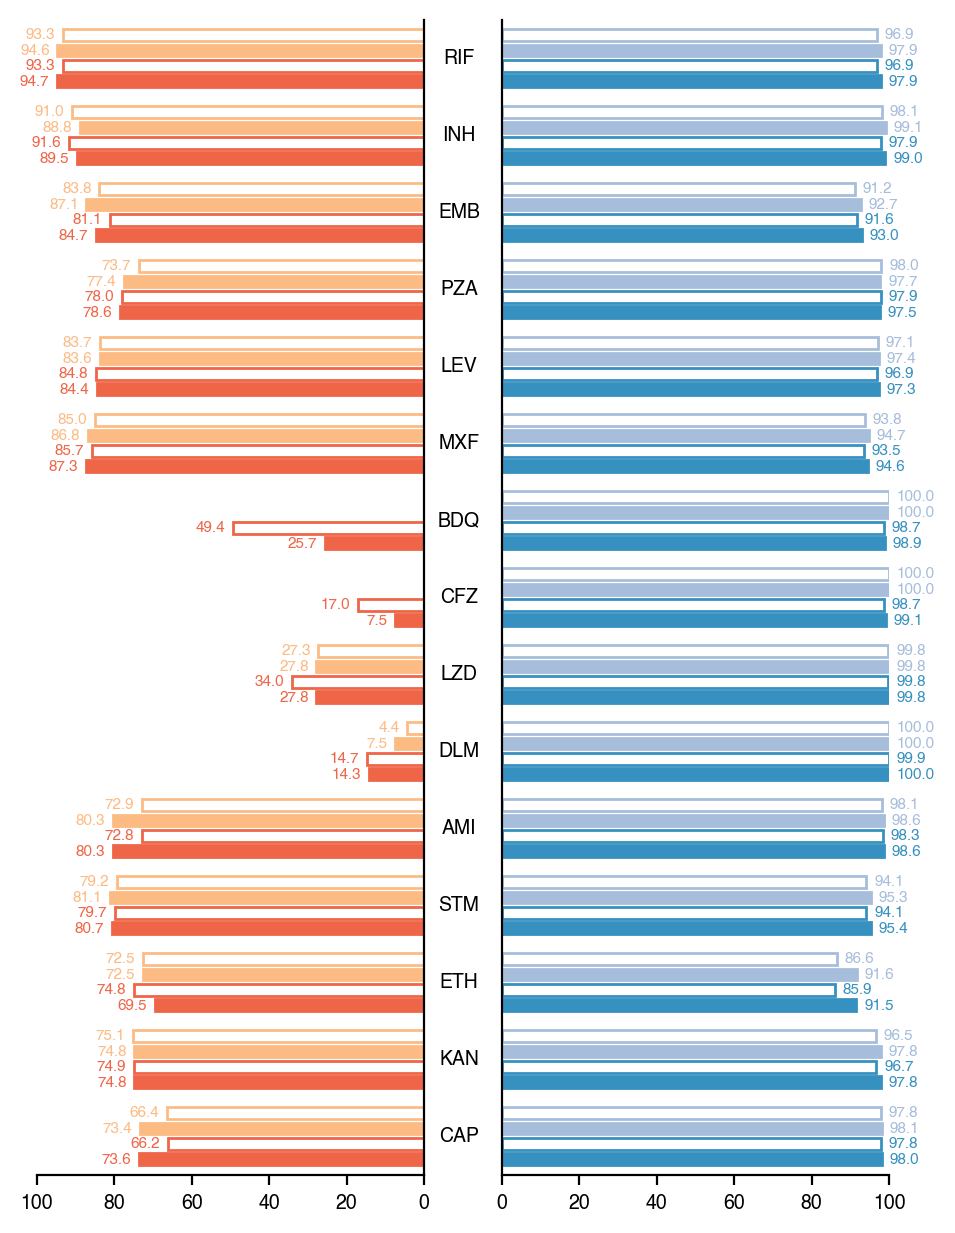

In [26]:
#training set (cryptic-v1.0.0) - BINARY
graphs.plot_bar_who(who_train, who_results,'figs/performance/bar-training-who1-who2.pdf', who_drugs, show_graph=True)

### WHOv1 (applied to validation set) vs published WHOv1 vs WHOv2 (applied to validation set) vs published WHOv2

In [130]:
#read in WHO results applied to our validation set
who_val = pd.read_csv('results/performance/whov1_whov2_validation.csv')
who_val.sort_values(['DRUG','catalogue'], inplace=True)
who_val = who_val[['catalogue', 'DRUG', 'SENSITIVITY2', 'SPECIFICITY2']].rename(columns={'SENSITIVITY2':'SENSITIVITY', 'SPECIFICITY2':'SPECIFICITY'})

In [131]:
who_val

,catalogue,DRUG,SENSITIVITY,SPECIFICITY
0,WHOv1,AMI,0.830189,0.989380
1,WHOv2,AMI,0.830189,0.989380
2,WHOv1,BDQ,0.000000,1.000000
3,WHOv2,BDQ,0.500000,0.989643
4,WHOv1,CAP,0.699160,0.983886
5,WHOv2,CAP,0.734454,0.983520
6,WHOv1,CFZ,0.000000,1.000000
7,WHOv2,CFZ,0.122642,0.987629
8,WHOv1,DLM,0.000000,1.000000
9,WHOv2,DLM,0.090909,0.999641


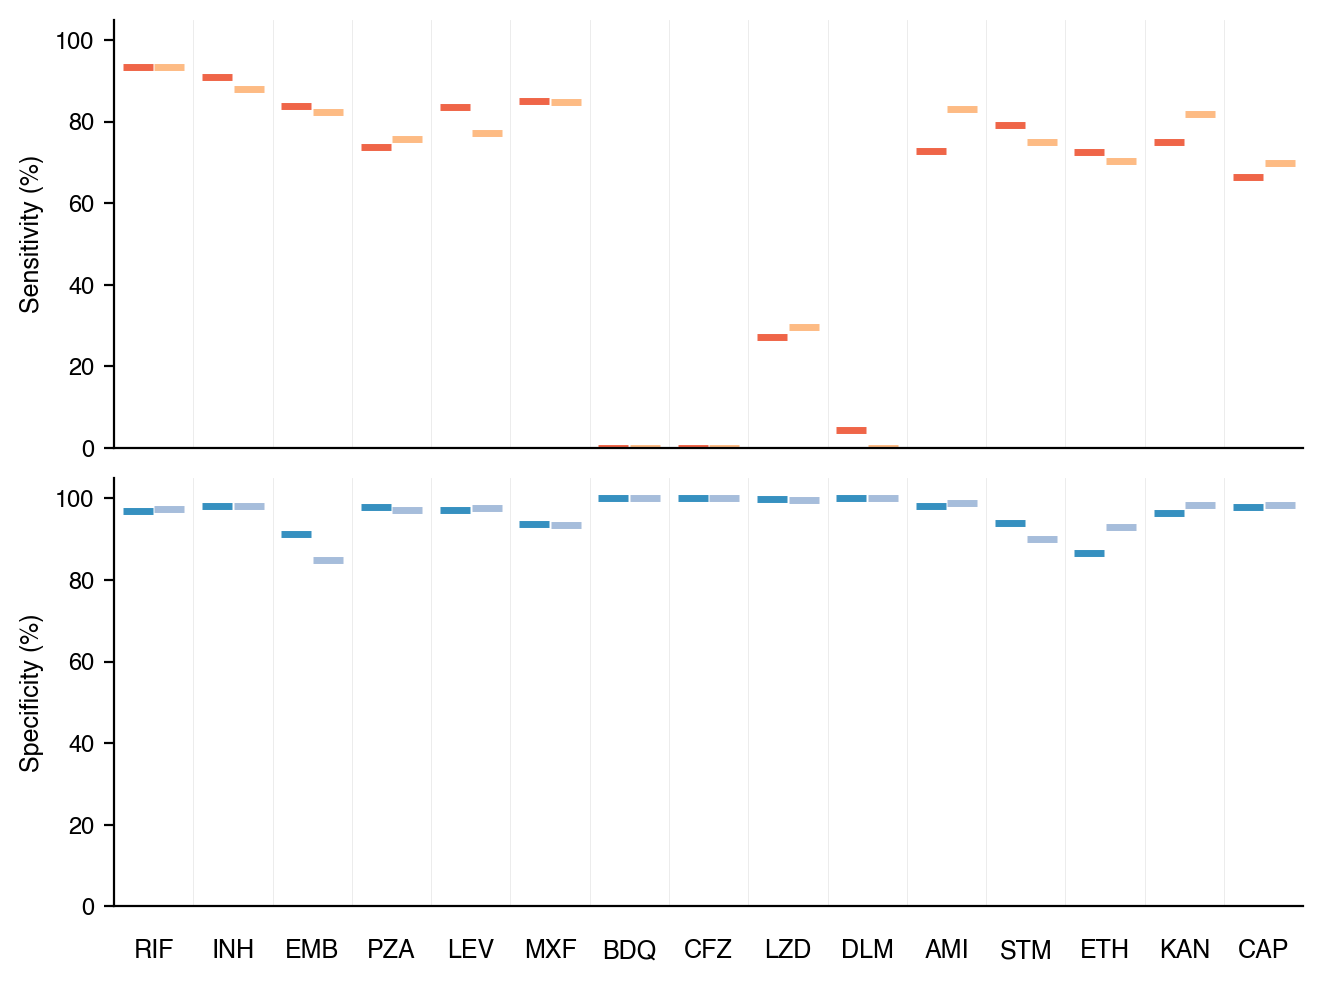

In [132]:
graphs.plot_scatter_who(who_val[who_val.catalogue=='WHOv1'], who_results[who_results.catalogue=="WHO1"],'figs/performance/scatter-validation-who1-who2.pdf', who_drugs, show_graph=True)

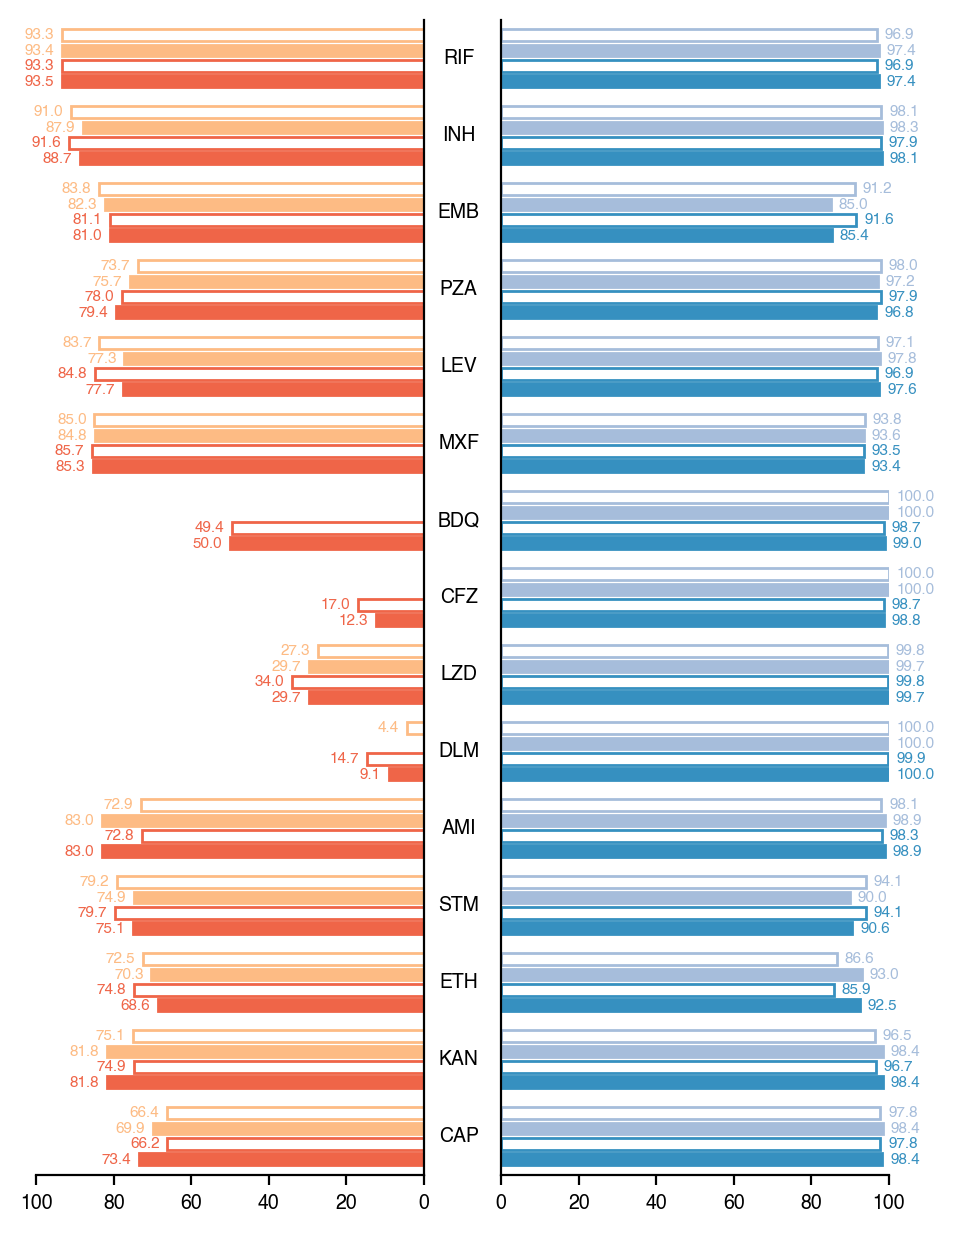

In [58]:
graphs.plot_bar_who(who_val, who_results,'figs/performance/bar-validation-who1-who2.pdf', who_drugs, show_graph=True)

### WHOv1 VS WHOv2 vs catomatic on training set (ternary)

In [59]:
results_training = pd.read_csv('results/performance/whov1_whov2_cat1_training.csv')
results_training.DRUG = results_training.DRUG.astype('category')
results_training.DRUG = results_training.DRUG.cat.set_categories(who_drugs)
results_training.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_training = results_training.iloc[::-1]
results_training = results_training[results_training.DRUG.isin(who_results.drug.values)]
results_training[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
23,23,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945534,0.987895,0.956970,0.917435,0.988510,12534,722,22035,270,406,1193
21,21,INH,WHOv1,0.934681,0.989184,0.957239,0.896574,0.989659,12249,856,22223,243,557,1032
22,22,INH,WHOv2,0.941997,0.988247,0.952987,0.904626,0.988850,12359,761,22031,262,542,1205
41,41,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.961417,0.985268,0.971120,0.943997,0.985760,10316,414,24812,371,198,870
39,39,RIF,WHOv1,0.962029,0.975051,0.977664,0.959828,0.975819,10489,414,24622,630,25,801
40,40,RIF,WHOv2,0.962385,0.974947,0.975825,0.959919,0.975780,10490,410,24556,631,28,866


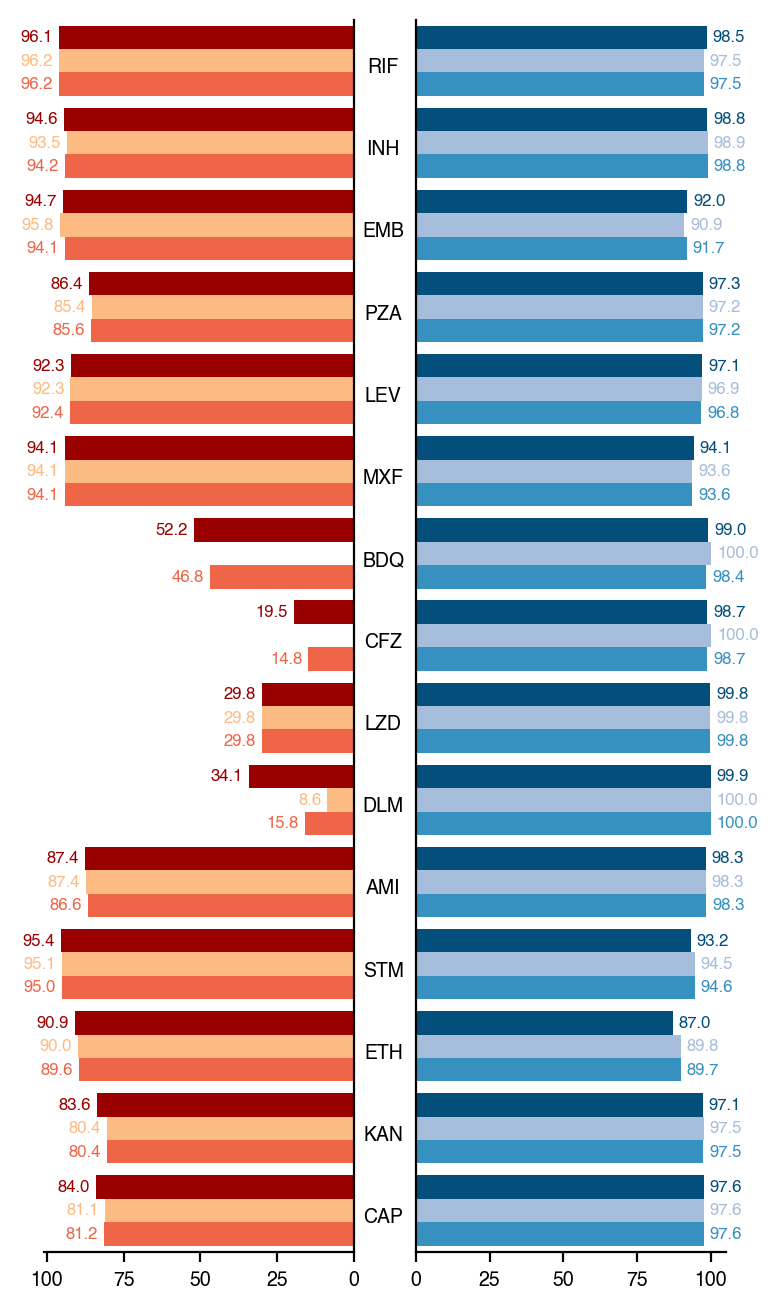

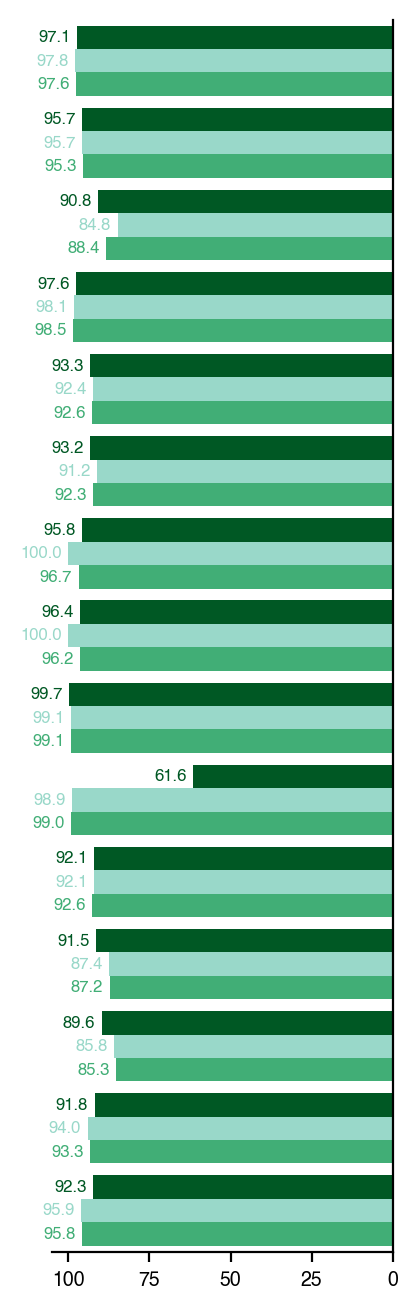

In [60]:
#training set (cryptic-v1.0.0)
graphs.plot_bar_catomatic(results_training, 'figs/performance/bar-training-who1-who2-cat1.pdf', who_drugs, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_training, 'figs/performance/bar-training-who1-who2-cat1-coverage.pdf', who_drugs, show_graph=True)

### WHOv1 VS WHOv2 vs catomatic on training set (binary)

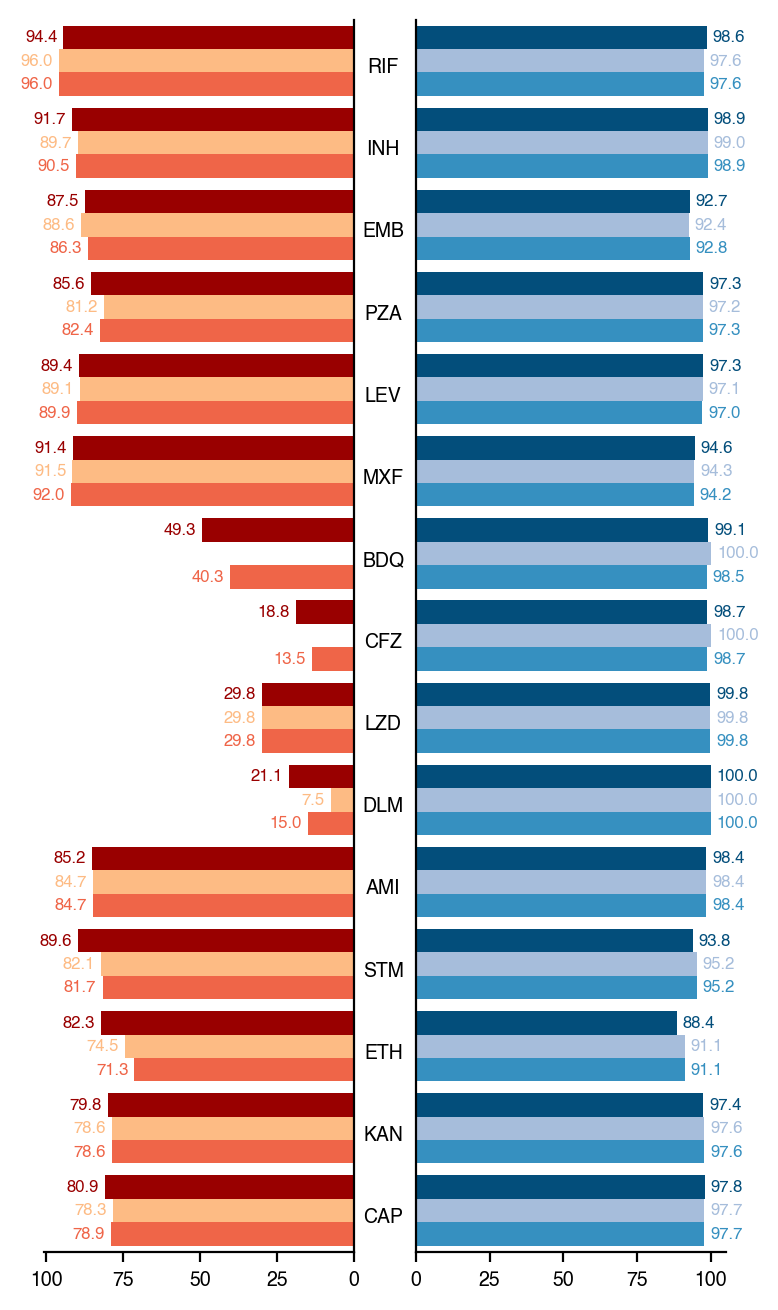

In [61]:
graphs.plot_bar_catomatic(results_training, 'figs/performance/bar-training-who1-who2-cat1-binary.pdf', who_drugs, show_graph=True,  sensitivity='SENSITIVITY2', specificity='SPECIFICITY2')

### WHOv1 VS WHOv2 vs catomatic on validation set (ternary)

In [ ]:
results_validation = pd.read_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_validation.DRUG = results_validation.DRUG.astype('category')
results_validation.DRUG = results_validation.DRUG.cat.set_categories(who_drugs)
results_validation.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_validation = results_validation[results_validation.DRUG.isin(who_results.drug.values)]
results_validation[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
6,6,CAP,WHOv1,0.792727,0.981294,0.955911,0.732773,0.982055,436,114,5141,98,45,222
8,8,CAP,MTBC-CRyPTICv1.1.1-2025.8,0.793478,0.980912,0.938904,0.736134,0.982055,438,114,5036,98,43,327
24,24,KAN,WHOv1,0.864008,0.982056,0.941895,0.852674,0.983212,845,133,6458,118,13,453
26,26,KAN,MTBC-CRyPTICv1.1.1-2025.8,0.867556,0.977415,0.916459,0.852674,0.979513,845,129,6232,144,17,653
18,18,ETH,WHOv1,0.867045,0.912434,0.841531,0.724596,0.926169,763,117,2928,281,173,597
20,20,ETH,MTBC-CRyPTICv1.1.1-2025.8,0.867797,0.857394,0.884956,0.729345,0.872044,768,117,2928,487,168,391


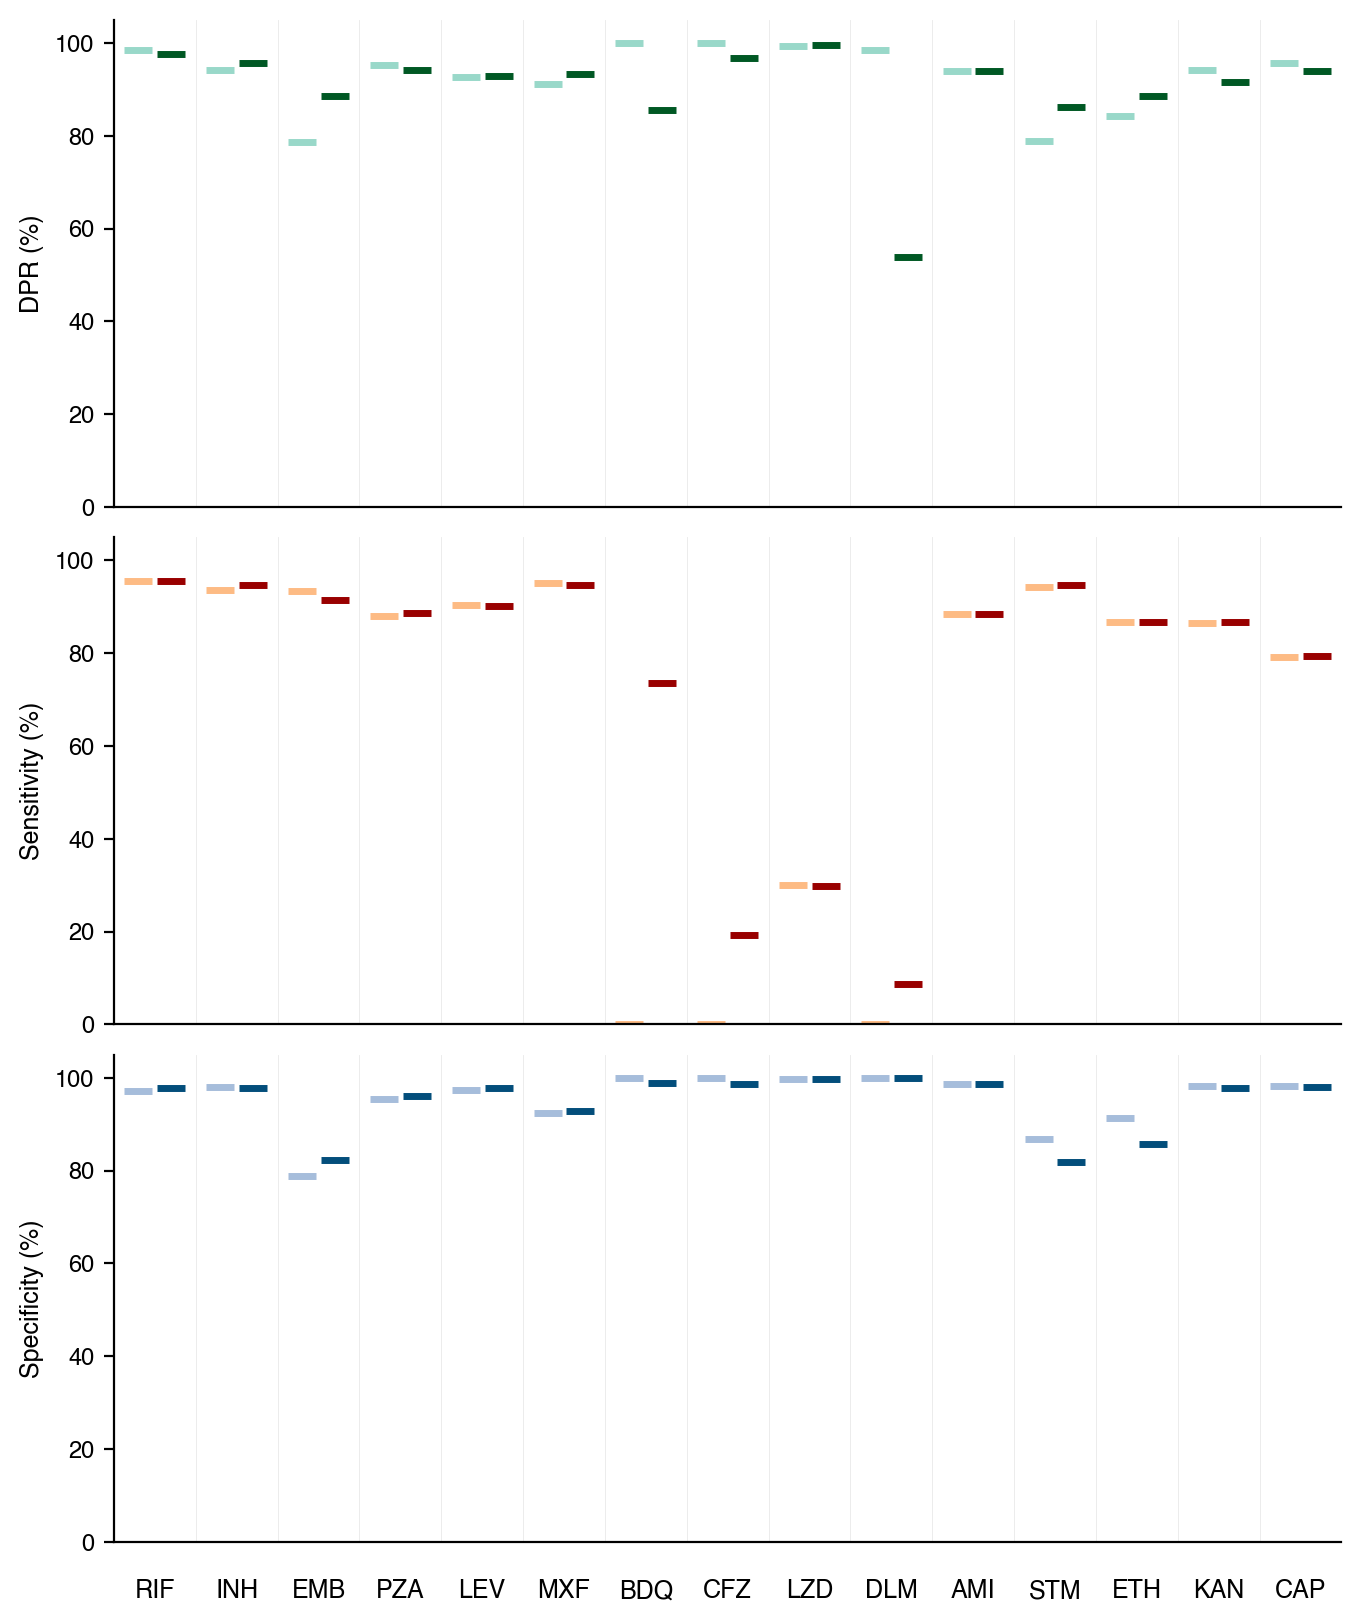

In [ ]:
graphs.plot_scatter_catomatic(results_validation[results_validation.catalogue.isin(['MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1'])], 'figs/performance/scatter-validation-who1-who2-cat1.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))


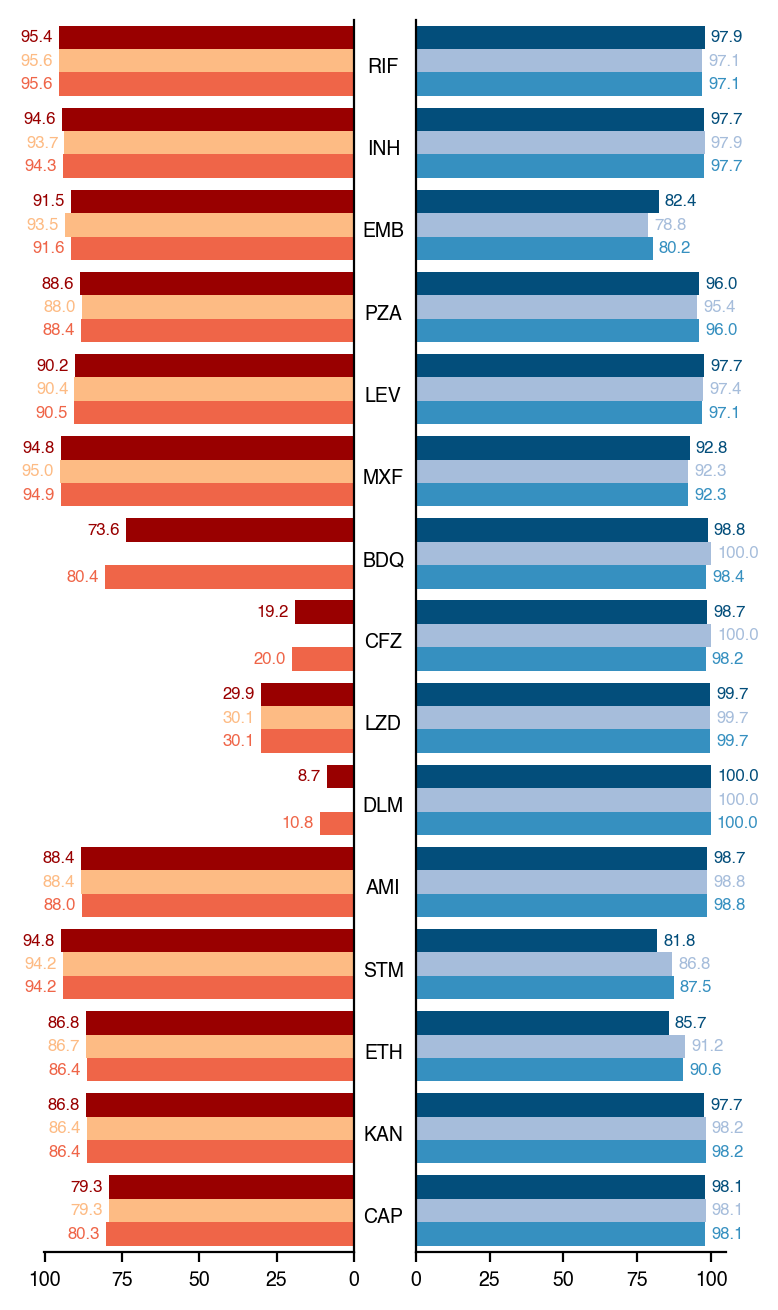

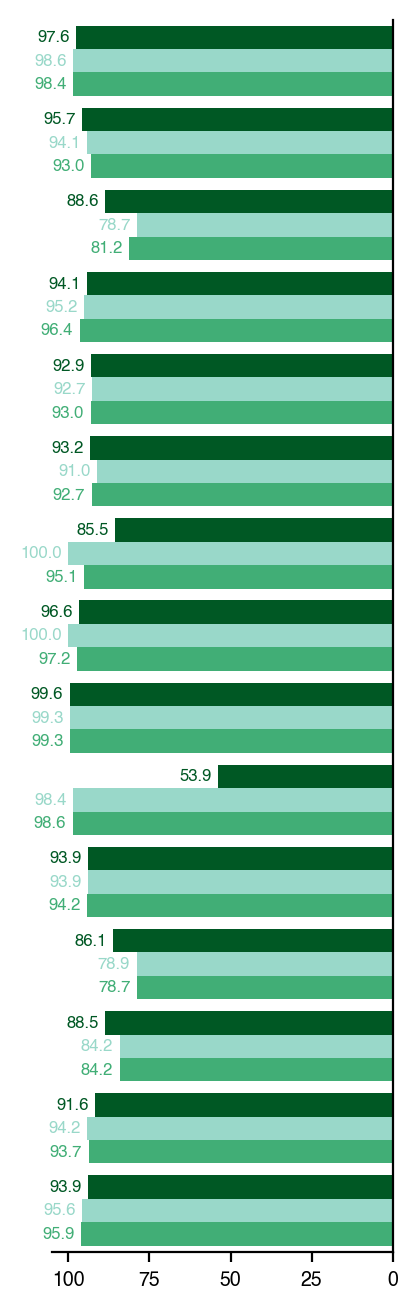

In [63]:
#training set (cryptic-v1.0.0)
graphs.plot_bar_catomatic(results_validation, 'figs/performance/bar-validation-who1-who2-cat1.pdf', who_drugs, show_graph=True, figsize=(4.4, 8))
graphs.plot_bar_catomatic_coverage(results_validation, 'figs/performance/bar-validation-who1-who2-cat1-coverage.pdf', who_drugs, show_graph=True, figsize=(2.2, 8))

### WHOv1 VS WHOv2 vs catomatic on validation set (binary)

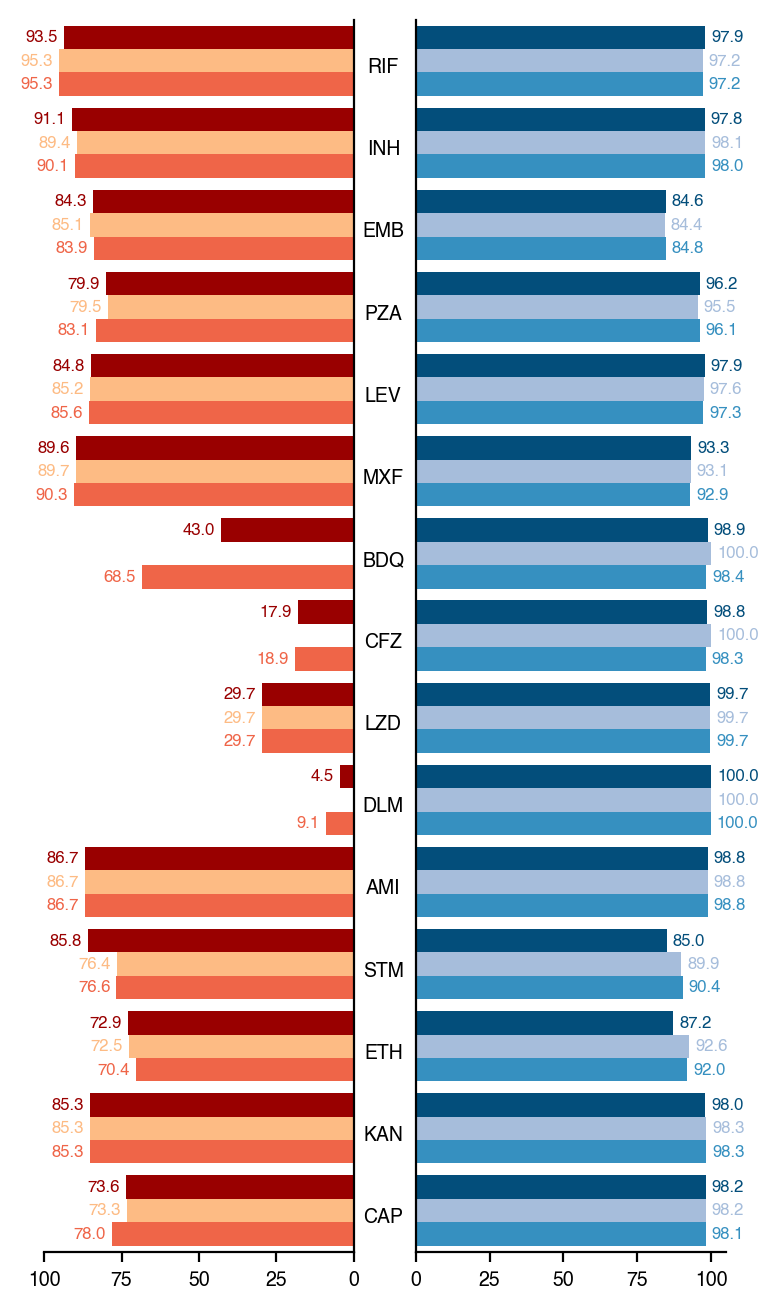

In [64]:
graphs.plot_bar_catomatic(results_validation, 'figs/performance/bar-validation-who1-who2-cat1-binary.pdf', who_drugs, show_graph=True,  sensitivity='SENSITIVITY2', specificity='SPECIFICITY2')

### WHOv1 without rules vs WHOv1 with rules vs catomaticv1 (ternary)

In [ ]:
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.astype('category')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.cat.set_categories(who_drugs)
results_val_no_rules.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_val_no_rules = results_val_no_rules.iloc[::-1]
results_val_no_rules = results_val_no_rules[results_val_no_rules.DRUG.isin(who_results.drug.values)]

results_val_no_rules[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
23,23,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945935,0.976962,0.957030,0.910813,0.978067,4759,272,5725,135,194,295
22,22,INH,WHOv1,0.936610,0.979374,0.940773,0.893589,0.980829,4669,316,5603,118,240,434
21,21,INH,WHOv1_no_rules,0.935825,0.980231,0.934974,0.881914,0.981641,4608,316,5603,113,301,439
41,41,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.954480,0.978878,0.975701,0.935092,0.979442,4005,191,6859,148,87,192
40,40,RIF,WHOv1,0.955504,0.971052,0.985630,0.952603,0.971663,4080,190,6843,204,13,152
39,39,RIF,WHOv1_no_rules,0.954073,0.979390,0.968821,0.921550,0.979997,3947,190,6843,144,146,212


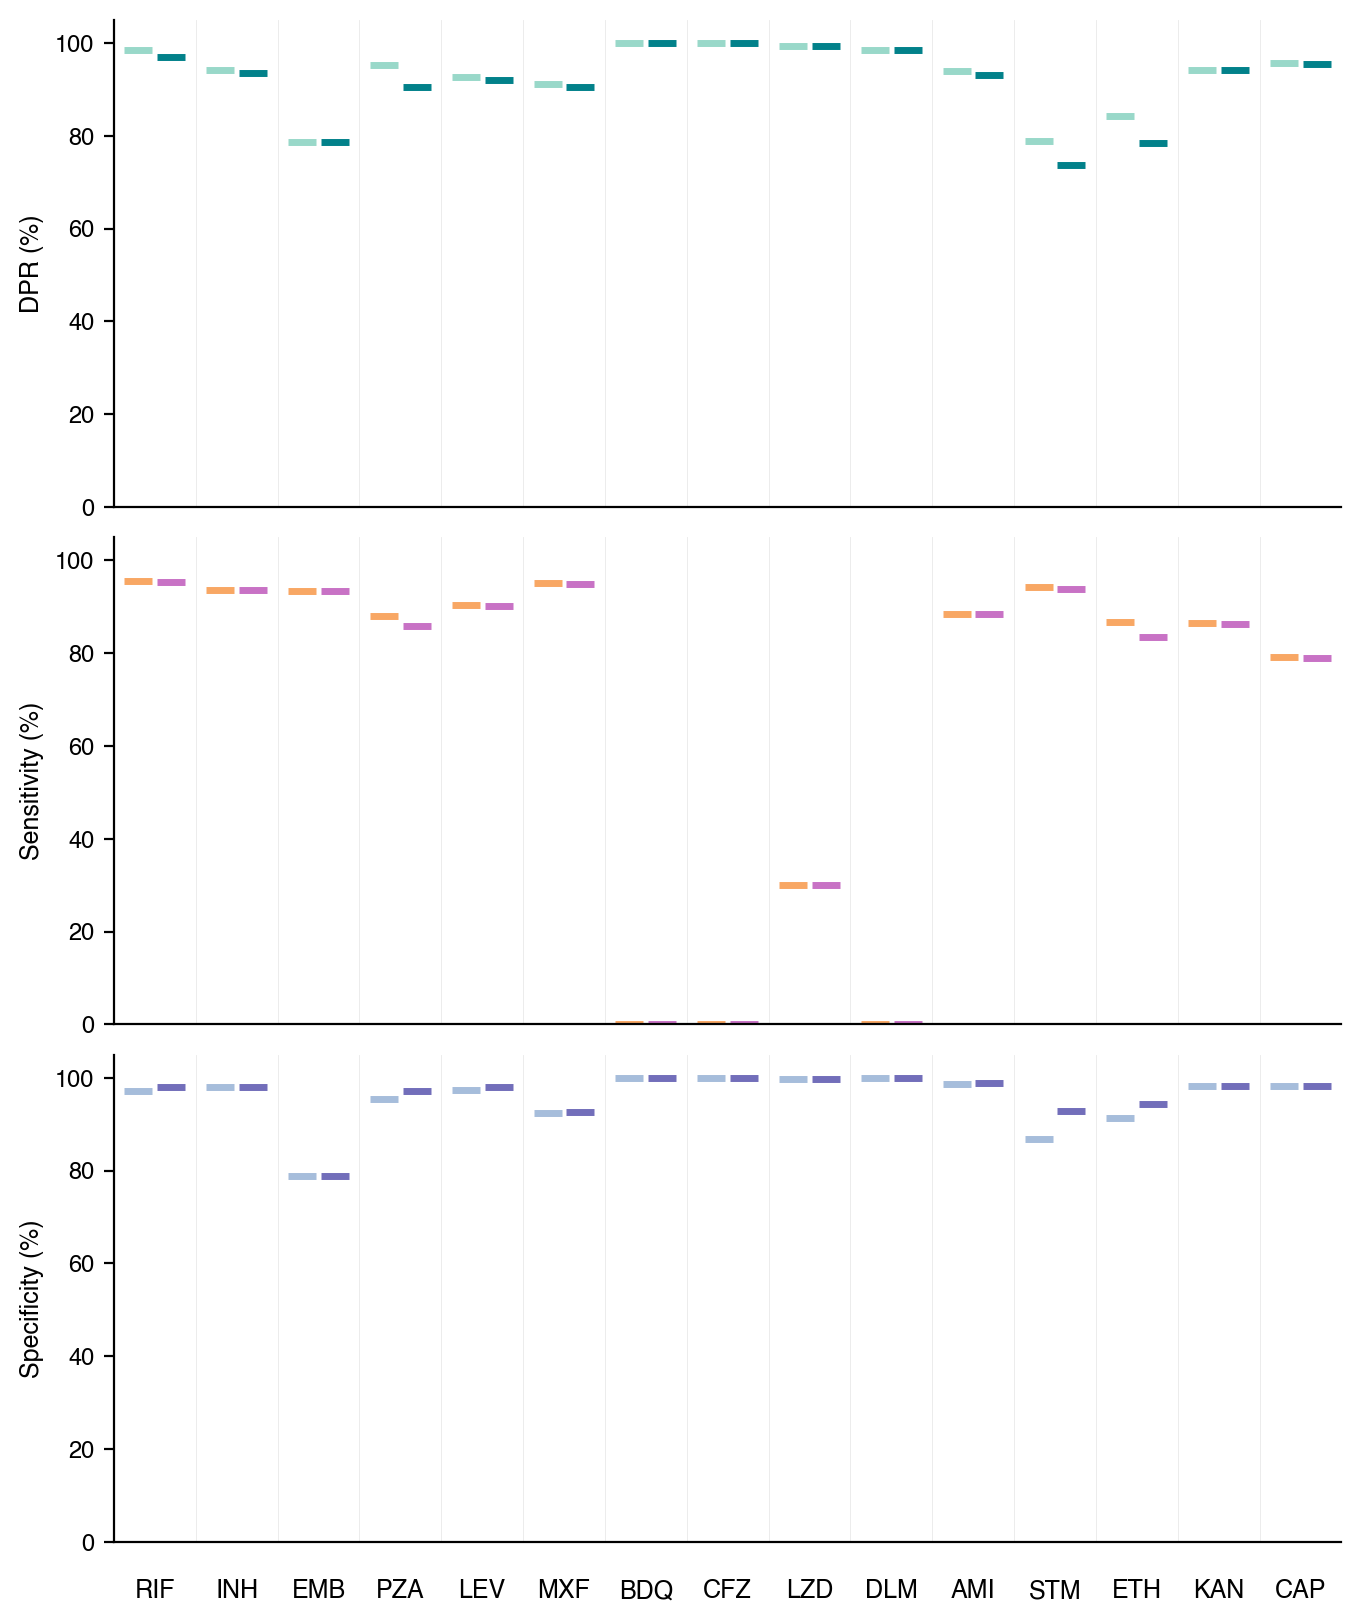

In [ ]:
graphs.plot_scatter_catomatic(results_val_no_rules[results_val_no_rules.catalogue.isin(['WHOv1', 'WHOv1_no_rules'])], 'figs/performance/scatter-validation-who1-who1_no_rules.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))

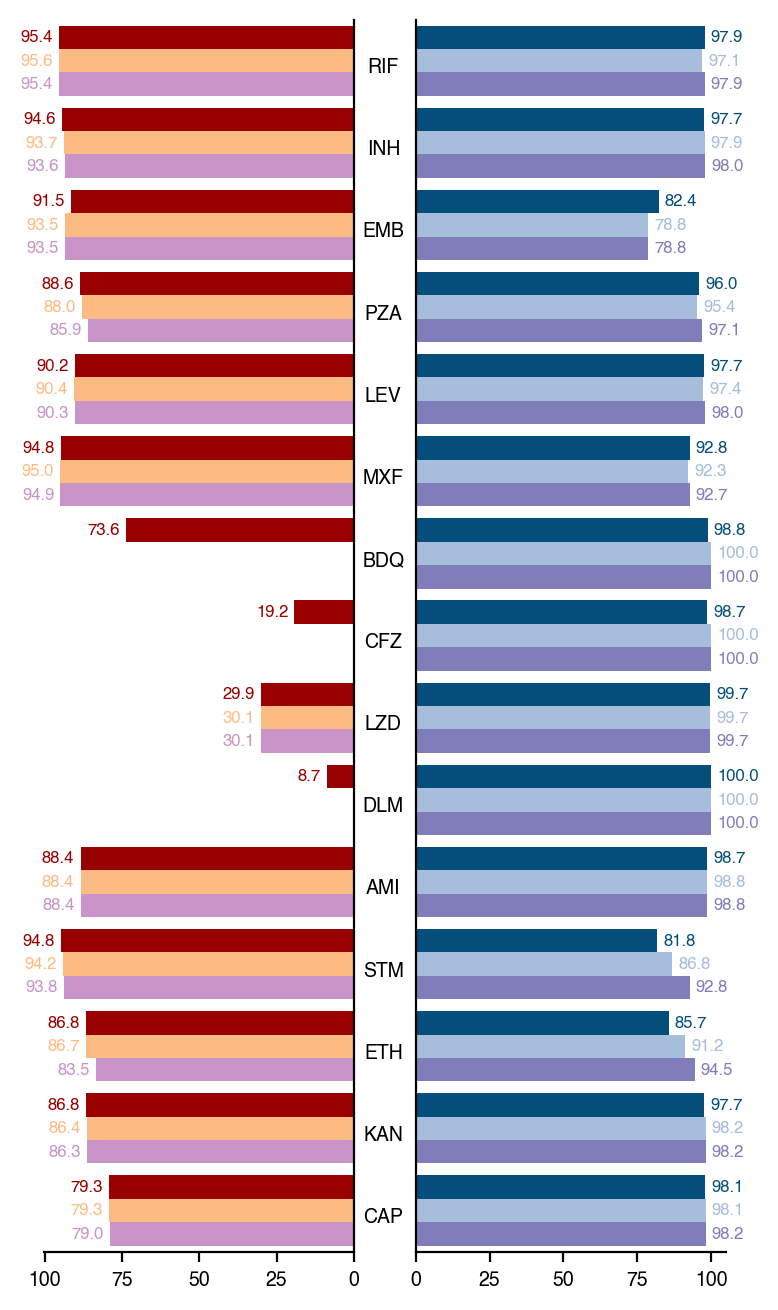

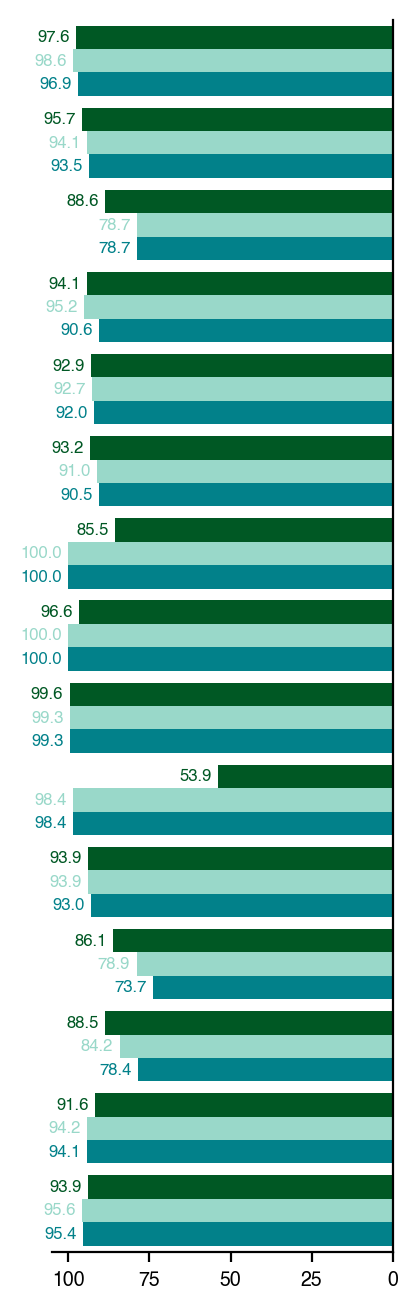

In [66]:
graphs.plot_bar_catomatic(results_val_no_rules, 'figs/performance/bar-validation-who1_no_rules-who1-cat1.pdf', who_drugs, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_val_no_rules, 'figs/performance/bar-validation-who1_no_rules-who1-cat1-coverage.pdf', who_drugs, show_graph=True)

### catomatic trained on training set vs catomatic trained on all data, applied to all data


In [152]:
results_all_samples = pd.read_csv('results/performance/cat_all_samples.csv')
results_all_samples.DRUG = results_all_samples.DRUG.astype('category')
results_all_samples.DRUG = results_all_samples.DRUG.cat.set_categories(who_drugs)
results_all_samples.sort_values(['DRUG','catalogue'], ascending=False, inplace=True)
results_all_samples = results_all_samples.iloc[::-1]
results_all_samples[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
28,28,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945644,0.985620,0.956984,0.915603,0.986342,17293,994,27760,405,600,1488
29,29,INH,MTBC-CRyPTICv3.4.0-2025.8,0.946292,0.985017,0.961145,0.926351,0.985769,17496,993,27743,422,398,1488
30,30,INH,WHOv1,0.935213,0.987193,0.953379,0.895748,0.987826,16918,1172,27826,361,797,1466
31,31,INH,WHOv2,0.942154,0.986083,0.947590,0.903743,0.986915,17069,1048,27491,388,770,1774
52,52,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.959467,0.983877,0.972206,0.941490,0.984392,14321,605,31671,519,285,1062
53,53,RIF,MTBC-CRyPTICv3.4.0-2025.8,0.959516,0.983928,0.974702,0.942673,0.984392,14339,605,31774,519,267,959


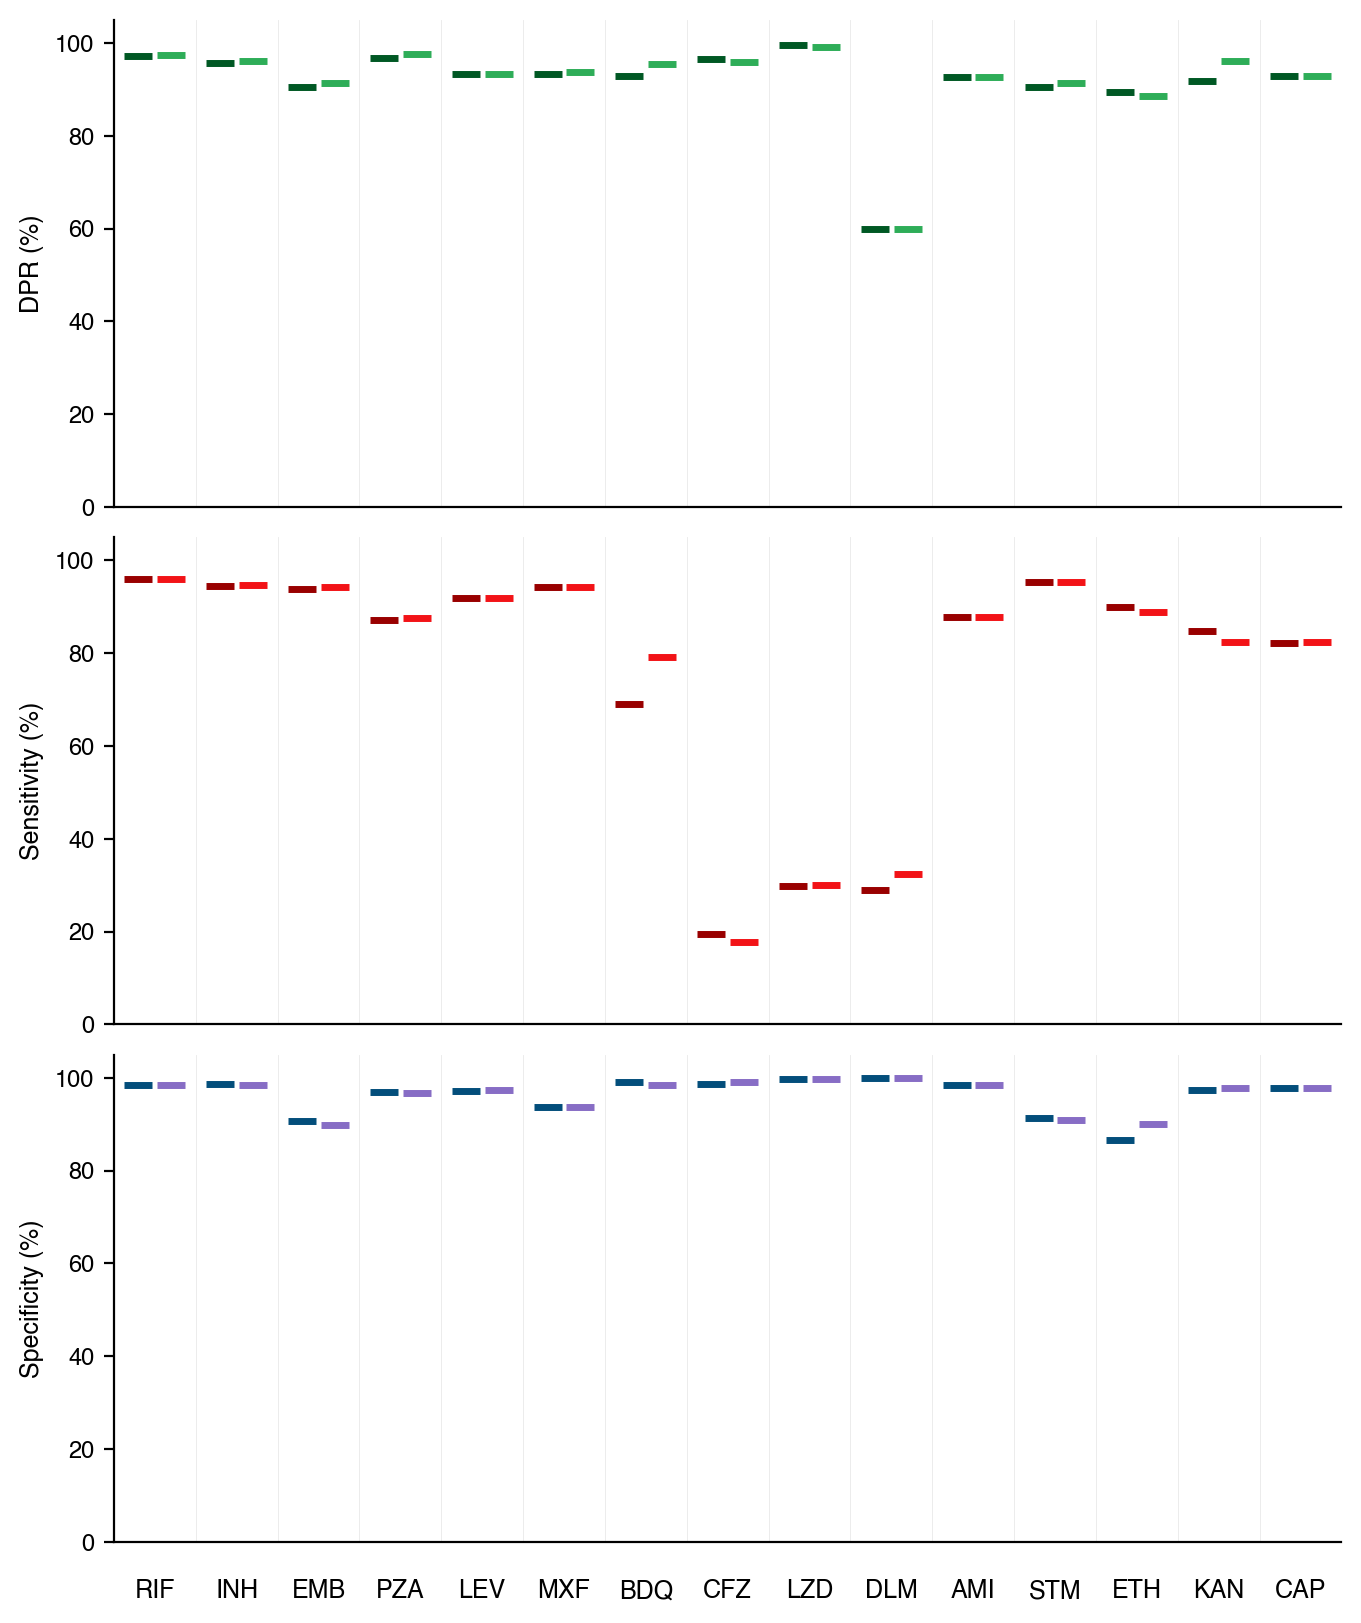

In [153]:
graphs.plot_scatter_catomatic(results_all_samples[results_all_samples.catalogue.isin(['MTBC-CRyPTICv1.1.1-2025.8', 'MTBC-CRyPTICv3.4.0-2025.8'])], 'figs/performance/scatter-cat1-cat2.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))

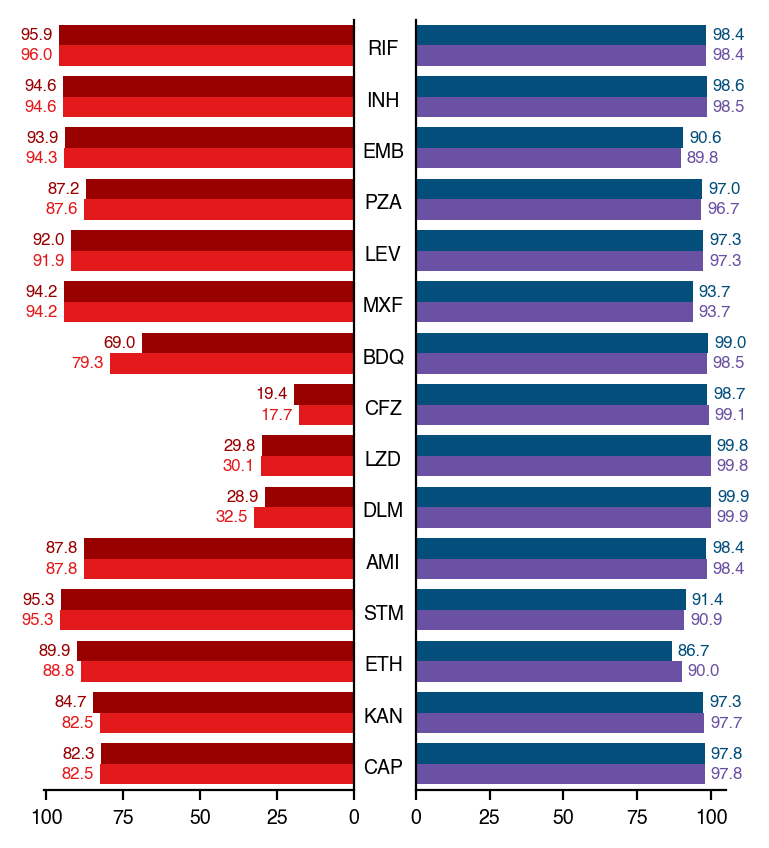

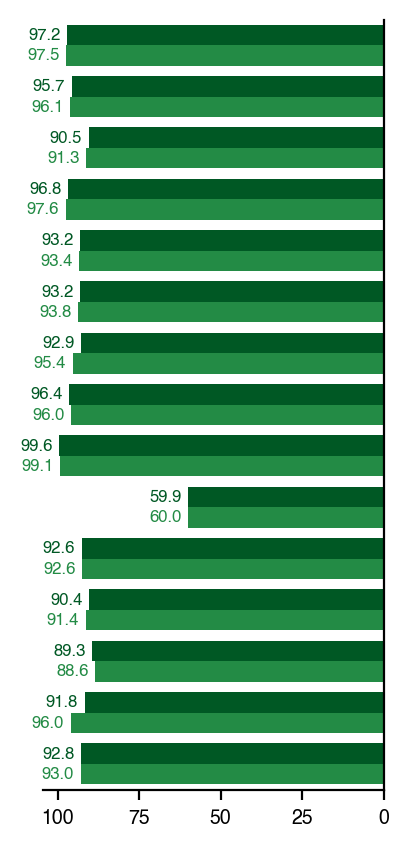

In [68]:
graphs.plot_bar_catomatic(results_all_samples, 'figs/performance/bar-all-samples-ternary.pdf', who_drugs, catalogues=['MTBC-CRyPTICv1.1.1-2025.8', 'MTBC-CRyPTICv3.4.0-2025.8'],  figsize=(4.4, 5), barwidth=0.4, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_all_samples, 'figs/performance/bar-all-samples-coverage.pdf', who_drugs, catalogues=['MTBC-CRyPTICv1.1.1-2025.8', 'MTBC-CRyPTICv3.4.0-2025.8'], figsize=(2.2, 5), barwidth=0.4, show_graph=True)

## Further analysis

In [69]:
train_phenotypes = functions.prep_phenotypes(
    'EMB',
    cryptic_tables_path+'DST_MEASUREMENTS.parquet',
    cryptic_tables_path+'GENOMES.parquet',
    cryptic_tables_path+'WGS_SAMPLES.parquet',
    version='v3.4.0',
    validation= False
    )

val_phenotypes = functions.prep_phenotypes(
'EMB',
cryptic_tables_path+'DST_MEASUREMENTS.parquet',
cryptic_tables_path+'GENOMES.parquet',
cryptic_tables_path+'WGS_SAMPLES.parquet',
version='v3.4.0',
validation= True
)

mutations = functions.prep_mutations(
    'data/mutations-v3.4.0/', 
    ['embA', 'embB'], 
    version='v3.4.0', 
    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
    var_path=cryptic_tables_path+'VARIANTS.parquet',
    train=False
)

In [70]:
train_phenotypes.rename(columns={'METHOD_MIC':'MIC'}, inplace=True)
train_phenotypes = train_phenotypes.dropna(subset=['MIC'])
train_mutations = mutations[mutations.UNIQUEID.isin(train_phenotypes.UNIQUEID.unique())]

catalogue_obj = RegressionBuilder(train_phenotypes, train_mutations, censored=False, tail_dilutions=3, genes=['embA', 'embB'])
model, effects = catalogue_obj.predict_effects(options={'ftol':1e-6, 'gtol':1e-4}, random_effects=False, cluster_distance=100, L2_penalties={}, b_bounds=(None, None))

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/intreg/meintreg.py:112: RuntimeWarning: divide by zero encountered in log
  np.log(
/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


embB@M306I


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:739: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mic_labels, fontsize=7)


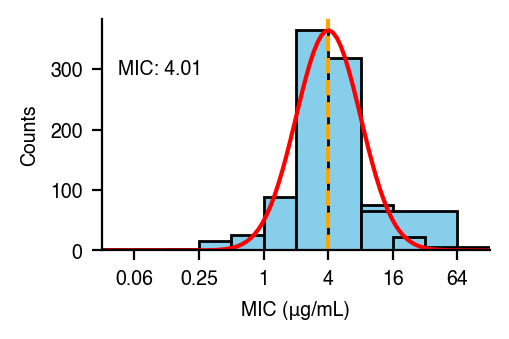

embB@M306V


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:739: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mic_labels, fontsize=7)


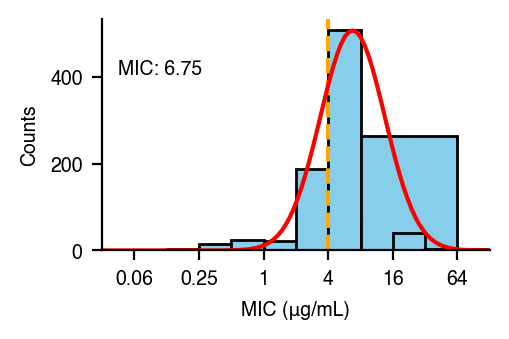

In [71]:
df = catalogue_obj.df.copy()
y_low, y_high = catalogue_obj.define_intervals(df)
df['y_low_log'] = y_low
df['y_high_log'] = y_high

graphs.plot_fitted_distribution(effects[effects.Mutation.isin(['embB@M306I', 'embB@M306V'])], df, 2, 20, -5, 7)

In [72]:
val_phenotypes.rename(columns={'METHOD_MIC':'MIC'}, inplace=True)
val_phenotypes = val_phenotypes.dropna(subset=['MIC'])
val_mutations = mutations[mutations.UNIQUEID.isin(val_phenotypes.UNIQUEID.unique())]

catalogue_obj = RegressionBuilder(val_phenotypes, val_mutations, censored=False, tail_dilutions=3, genes=['embA', 'embB'])
model, effects = catalogue_obj.predict_effects(options={'ftol':1e-6, 'gtol':1e-4}, random_effects=False, cluster_distance=100, L2_penalties={}, b_bounds=(None, None))

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/intreg/meintreg.py:112: RuntimeWarning: divide by zero encountered in log
  np.log(
/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


embB@M306I


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:739: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mic_labels, fontsize=7)


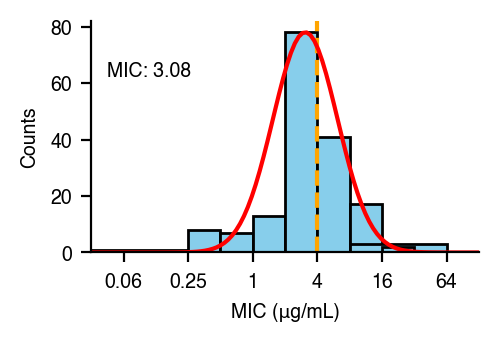

embB@M306V


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:739: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mic_labels, fontsize=7)


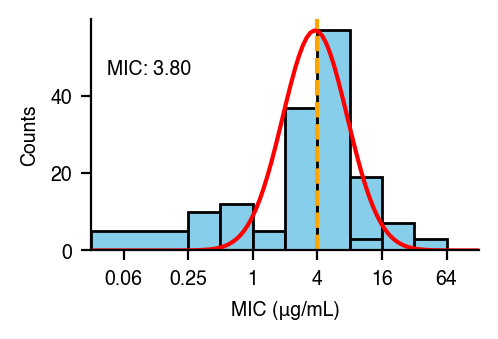

In [73]:
df = catalogue_obj.df.copy()
y_low, y_high = catalogue_obj.define_intervals(df)
df['y_low_log'] = y_low
df['y_high_log'] = y_high

graphs.plot_fitted_distribution(effects[effects.Mutation.isin(['embB@M306I', 'embB@M306V'])], df, 2, 20, -5, 7)

#  Results tables

In [ ]:
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.astype('category')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.cat.set_categories(who_drugs)
results_val_no_rules.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_val_no_rules = results_val_no_rules.iloc[::-1]
results_val_no_rules = results_val_no_rules[results_val_no_rules.DRUG.isin(who_results.drug.values)]

df = results_val_no_rules.copy()
df = df[["DRUG", "catalogue", "SENSITIVITY", "SPECIFICITY", "COVERAGE"]]
df_pivot = df.pivot(index="DRUG", columns="catalogue", values=["SENSITIVITY", "SPECIFICITY", "COVERAGE"])
df_pivot.columns = [f"{cat}_{metric}" for metric, cat in df_pivot.columns]
df_pivot = df_pivot.reset_index()
df_pivot

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
23,23,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945935,0.976962,0.957030,0.910813,0.978067,4759,272,5725,135,194,295
22,22,INH,WHOv1,0.936610,0.979374,0.940773,0.893589,0.980829,4669,316,5603,118,240,434
21,21,INH,WHOv1_no_rules,0.935825,0.980231,0.934974,0.881914,0.981641,4608,316,5603,113,301,439
41,41,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.954480,0.978878,0.975701,0.935092,0.979442,4005,191,6859,148,87,192
40,40,RIF,WHOv1,0.955504,0.971052,0.985630,0.952603,0.971663,4080,190,6843,204,13,152
39,39,RIF,WHOv1_no_rules,0.954073,0.979390,0.968821,0.921550,0.979997,3947,190,6843,144,146,212


In [91]:
results_all = pd.read_csv('results/performance/cat_all_samples.csv')
results_all.DRUG = results_all.DRUG.astype('category')
results_all.DRUG = results_all.DRUG.cat.set_categories(who_drugs)
results_all.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_all = results_all.iloc[::-1]
results_all = results_all[results_all.DRUG.isin(who_results.drug.values)]

df = results_all.copy()
df = df[["DRUG", "catalogue", "SENSITIVITY", "SPECIFICITY", "COVERAGE"]]
df_pivot = df.pivot(index="DRUG", columns="catalogue", values=["SENSITIVITY", "SPECIFICITY", "COVERAGE"])
df_pivot.columns = [f"{cat}_{metric}" for metric, cat in df_pivot.columns]
df_pivot = df_pivot.reset_index()
df_pivot

,DRUG,MTBC-CRyPTICv1.1.1-2025.8_SENSITIVITY,MTBC-CRyPTICv3.4.0-2025.8_SENSITIVITY,WHOv1_SENSITIVITY,WHOv2_SENSITIVITY,MTBC-CRyPTICv1.1.1-2025.8_SPECIFICITY,MTBC-CRyPTICv3.4.0-2025.8_SPECIFICITY,WHOv1_SPECIFICITY,WHOv2_SPECIFICITY,MTBC-CRyPTICv1.1.1-2025.8_COVERAGE,MTBC-CRyPTICv3.4.0-2025.8_COVERAGE,WHOv1_COVERAGE,WHOv2_COVERAGE
0,INH,0.945644,0.946292,0.935213,0.942154,0.985620,0.985017,0.987193,0.986083,0.956984,0.961145,0.953379,0.947590
1,RIF,0.959467,0.959516,0.960192,0.960519,0.983877,0.983928,0.974179,0.974078,0.972206,0.974702,0.979551,0.977736
2,PZA,0.871548,0.875633,0.863187,0.865477,0.969990,0.966762,0.968040,0.969606,0.967505,0.975638,0.974109,0.979739
3,EMB,0.938530,0.943092,0.951458,0.934306,0.906123,0.897554,0.892758,0.902203,0.904721,0.912953,0.837438,0.871452
4,BDQ,0.689600,0.792513,0.000000,0.754177,0.989865,0.984591,1.000000,0.984212,0.929151,0.953861,1.000000,0.962870
5,LZD,0.298246,0.301170,0.299120,0.299120,0.997692,0.997681,0.997681,0.997681,0.996377,0.991493,0.991440,0.991440
6,MXF,0.942167,0.941687,0.942966,0.942795,0.936840,0.937332,0.932308,0.931858,0.931897,0.938199,0.911323,0.923968
7,LEV,0.919563,0.919437,0.920157,0.920715,0.972552,0.973488,0.969960,0.968458,0.931866,0.933771,0.924639,0.927267
8,CFZ,0.194030,0.177143,0.000000,0.157895,0.987047,0.991349,1.000000,0.985688,0.964413,0.959696,1.000000,0.964413
9,DLM,0.289474,0.325000,0.068323,0.147727,0.999363,0.998981,0.999769,0.999537,0.599278,0.599955,0.987811,0.989166
